# Fairness-Aware Property Assessment Modeling in Cook County

# PART I: Problem, Data, and Fairness Framework

## 1. Project Motivation

Property valuation models affect more than predictive accuracy. In a property-tax system, systematic overvaluation or undervaluation can translate into unequal tax burdens across homeowners and communities.

A model may achieve strong aggregate predictive performance while producing systematically different errors for different property-value or demographic groups. Therefore, evaluating a property assessment model requires examining both:

1. **Predictive accuracy** — how closely predicted property values match observed sale prices.
2. **Assessment fairness** — whether the magnitude and direction of prediction errors differ systematically across groups.

This project develops and evaluates property valuation models using residential property sales from Cook County, Illinois. In addition to property characteristics, Census tract-level demographic information will be incorporated to examine whether model errors differ across socioeconomic and demographic contexts.

The project will ultimately compare:

- a conventional linear-regression baseline,
- a stronger predictive benchmark,
- and a fairness-aware model that explicitly penalizes undesirable directional assessment errors.

The central research question is:

> **Can a property valuation model maintain competitive predictive accuracy while reducing systematic assessment disparities across property-value and demographic groups?**

## 2. What Does "Fair" Mean in This Project?

Fairness in property assessment is not equivalent to requiring every individual prediction to be correct.

Instead, we are interested in whether prediction errors exhibit systematic patterns across groups.

For a property with observed sale price $y_i$ and predicted value $\hat{y}_i$:

- $ \hat{y}_i > y_i\ $ represents **overassessment**
- $ \hat{y}_i < y_i\ $ represents **underassessment**

A model may have reasonable overall RMSE while still disproportionately overassessing one segment of the housing market.

We will therefore evaluate models along several dimensions:

### Predictive Performance
- Root Mean Squared Error (RMSE)
- Mean Absolute Error (MAE)
- Mean Absolute Percentage Error (MAPE)

### Directional Assessment Behavior
- Mean residual
- Overassessment rate
- Underassessment rate
- Assessment ratio

$$
\text{Assessment Ratio}_i = \frac{\hat{y}_i}{y_i}
$$

An assessment ratio greater than 1 indicates overassessment, while a ratio below 1 indicates underassessment.

### Group-Level Fairness

These quantities will later be compared across:

1. Property-value groups
2. Census tract income groups
3. Census tract demographic composition
4. Geographic areas

The goal is not to assume that property value itself represents race or income. Instead, demographic conclusions will only be made after explicitly joining external Census/ACS demographic data.

In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import zipfile
import os
import requests

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error,
    mean_absolute_percentage_error,
    r2_score,
)

from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import HistGradientBoostingRegressor

In [2]:
with zipfile.ZipFile('cook_county_data.zip', 'r') as z:
    with z.open("cook_county_train.csv") as f:
        data = pd.read_csv(f)

print("Dataset shape:", data.shape)
data.head()

Dataset shape: (204792, 63)


,Unnamed: 0,PIN,Property Class,Neighborhood Code,Land Square Feet,Town Code,Apartments,Wall Material,Roof Material,Basement,...,Sale Month of Year,Sale Half of Year,Most Recent Sale,Age Decade,Pure Market Filter,Garage Indicator,Neigborhood Code (mapping),Town and Neighborhood,Description,Lot Size
0,0,17294100610000,203,50,2500.0,76,0.0,2.0,1.0,1.0,...,9,2,1.0,13.2,0,0.0,50,7650,"This property, sold on 09/14/2015, is a one-st...",2500.0
1,1,13272240180000,202,120,3780.0,71,0.0,2.0,1.0,1.0,...,5,1,1.0,9.6,1,1.0,120,71120,"This property, sold on 05/23/2018, is a one-st...",3780.0
2,2,25221150230000,202,210,4375.0,70,0.0,2.0,1.0,2.0,...,2,1,0.0,11.2,1,1.0,210,70210,"This property, sold on 02/18/2016, is a one-st...",4375.0
3,3,10251130030000,203,220,4375.0,17,0.0,3.0,1.0,1.0,...,7,2,1.0,6.3,1,1.0,220,17220,"This property, sold on 07/23/2013, is a one-st...",4375.0
4,4,31361040550000,202,120,8400.0,32,0.0,3.0,1.0,2.0,...,6,1,0.0,6.3,1,1.0,120,32120,"This property, sold on 06/10/2016, is a one-st...",8400.0


In [3]:
print(f"Number of observations: {data.shape[0]:,}")
print(f"Number of columns: {data.shape[1]}")

data.info()

Number of observations: 204,792
Number of columns: 63
<class 'pandas.DataFrame'>
RangeIndex: 204792 entries, 0 to 204791
Data columns (total 63 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Unnamed: 0                  204792 non-null  int64  
 1   PIN                         204792 non-null  int64  
 2   Property Class              204792 non-null  int64  
 3   Neighborhood Code           204792 non-null  int64  
 4   Land Square Feet            204792 non-null  float64
 5   Town Code                   204792 non-null  int64  
 6   Apartments                  204792 non-null  float64
 7   Wall Material               204792 non-null  float64
 8   Roof Material               204792 non-null  float64
 9   Basement                    204792 non-null  float64
 10  Basement Finish             204792 non-null  float64
 11  Central Heating             204792 non-null  float64
 12  Other Heating               2

## 4. Core Variables

The raw dataset contains property characteristics, transaction information, geographic identifiers, and assessment-related variables.

Before performing exploratory analysis, we first identify the variables most relevant to the project:

### Outcome
- `Sale Price`

### Property Characteristics
Examples include:
- `Building Square Feet`
- `Land Square Feet`
- `Bathrooms`
- `Age`
- `Property Class`
- construction and condition variables
- garage and improvement characteristics

### Geography
- `Census Tract`
- `Latitude`
- `Longitude`
- `Town Code`
- `Neighborhood Code`

### Time
- `Sale Year`
- `Sale Quarter`
- `Sale Month of Year`

The `Census Tract` variable is especially important because it potentially provides a direct key for joining tract-level demographic information from the American Community Survey.

In [4]:
{
    "shape": data.shape,
    "sale_year_range": (
        data["Sale Year"].min(),
        data["Sale Year"].max()
    ),
    "n_census_tracts": data["Census Tract"].nunique(),
    "missing_census_tract_pct": data["Census Tract"].isna().mean() * 100,
    "missing_latitude_pct": data["Latitude"].isna().mean() * 100,
    "missing_longitude_pct": data["Longitude"].isna().mean() * 100,
}

{'shape': (204792, 63),
 'sale_year_range': (np.int64(2013), np.int64(2019)),
 'n_census_tracts': 1265,
 'missing_census_tract_pct': np.float64(0.0),
 'missing_latitude_pct': np.float64(0.0),
 'missing_longitude_pct': np.float64(0.0)}

In [5]:
data[
    [
        "Census Tract",
        "Latitude",
        "Longitude",
        "Town Code",
        "Neighborhood Code",
        "Sale Year",
        "Sale Price"
    ]
].head(10)

,Census Tract,Latitude,Longitude,Town Code,Neighborhood Code,Sale Year,Sale Price
0,600600.0,41.840803,-87.654264,76,50,2015,1
1,200100.0,41.933016,-87.735966,71,120,2018,285000
2,491400.0,41.686738,-87.616496,70,210,2016,22000
3,810301.0,42.019937,-87.701482,17,220,2013,225000
4,830300.0,41.476430,-87.682236,32,120,2016,22600
5,640300.0,41.784580,-87.769661,72,380,2018,1
6,828202.0,41.557900,-87.547981,37,181,2017,100000
7,801606.0,42.118618,-87.855616,25,52,2016,795000
8,160800.0,41.953313,-87.712016,71,70,2016,675000
9,804105.0,42.091755,-88.101858,29,33,2019,270000


### Examining Data Structure/Quality

The raw Cook County dataset contains **204792 property-sale observations and 63 variables**, covering transactions from **2013 through 2019**.

Geographic coverage is strong for the planned demographic analysis:

- The dataset contains **1,265 unique Census tracts**.
- Census tract, latitude, and longitude information are complete, with **0% missingness**.
- Therefore, tract-level demographic enrichment appears feasible without discarding a meaningful portion of the housing dataset.

The initial inspection also reveals transactions recorded at extremely small sale prices, including \$1 sales. These likely represent non-market or nominal transactions and should be investigated during the data-cleaning stage rather than treated as ordinary residential sales.

## 5. Census Geography Validation

To incorporate demographic information, each property must be linked to a Census tract.

The Census Bureau identifies Census tracts using a six-digit tract code within a state and county. For Cook County:

- Illinois state FIPS code: `17`
- Cook County FIPS code: `031`

The housing dataset stores Census tract identifiers numerically, which may remove leading zeroes. We therefore standardize the tract variable as a six-character string before attempting the demographic join.

The complete tract GEOID can then be represented as:

$$
\text{GEOID} =
\text{State FIPS} +
\text{County FIPS} +
\text{Tract Code}
$$

For Cook County, this gives an 11-digit identifier beginning with `17031`.

In [6]:
# Preserve missing values while creating a standardized six-digit tract code
data["Census Tract Code"] = (
    data["Census Tract"]
    .astype("Int64")
    .astype("string")
    .str.zfill(6)
)

# Construct full 11-digit Census tract GEOID
data["Census Tract GEOID"] = (
    "17031" + data["Census Tract Code"]
)

data[
    [
        "Census Tract",
        "Census Tract Code",
        "Census Tract GEOID"
    ]
].head(10)

,Census Tract,Census Tract Code,Census Tract GEOID
0,600600.0,600600,17031600600
1,200100.0,200100,17031200100
2,491400.0,491400,17031491400
3,810301.0,810301,17031810301
4,830300.0,830300,17031830300
5,640300.0,640300,17031640300
6,828202.0,828202,17031828202
7,801606.0,801606,17031801606
8,160800.0,160800,17031160800
9,804105.0,804105,17031804105


In [7]:
print("Unique raw tracts:", data["Census Tract"].nunique())
print("Unique standardized tracts:", data["Census Tract Code"].nunique())

print("\nTract-code length distribution:")
print(data["Census Tract Code"].str.len().value_counts(dropna=False))

print("\nSample standardized tracts:")
print(
    data[
        ["Census Tract", "Census Tract Code", "Census Tract GEOID"]
    ]
    .drop_duplicates()
    .sort_values("Census Tract Code")
    .head(15)
)

Unique raw tracts: 1265
Unique standardized tracts: 1265

Tract-code length distribution:
Census Tract Code
6    204792
Name: count, dtype: Int64

Sample standardized tracts:
        Census Tract Census Tract Code Census Tract GEOID
6603         10100.0            010100        17031010100
2679         10201.0            010201        17031010201
2644         10202.0            010202        17031010202
9933         10300.0            010300        17031010300
14568        10400.0            010400        17031010400
63862        10501.0            010501        17031010501
40883        10502.0            010502        17031010502
179851       10503.0            010503        17031010503
2877         10600.0            010600        17031010600
816          10701.0            010701        17031010701
10303        10702.0            010702        17031010702
18515        20100.0            020100        17031020100
237          20200.0            020200        17031020200
1696         

### Census Tract Identifier Validation

Standardizing the Census tract variable successfully preserved all **1,265 unique tract identifiers** while converting each non-missing value to the six-digit format used by the Census Bureau.

Of the 204792 property-sale observations, **all have a valid six-digit tract code**, with only one observation missing geographic information. The resulting 11-digit GEOID combines the Illinois state FIPS (`17`), Cook County FIPS (`031`), and six-digit tract code.

Because no tract identifiers were lost or duplicated during standardization, the resulting GEOID is a suitable candidate key for joining external tract-level demographic data.

## 6. Validate Property Tracts Against Official Census Geography

Before attaching demographic variables, the locally constructed Census GEOIDs should be compared against an official list of Census tracts.

This validation serves two purposes:

1. It verifies that the housing dataset's tract coding is compatible with Census geography.
2. It allows us to measure the expected demographic-data match rate before performing the actual merge.

We use the 2019 ACS 5-year geography because the housing transactions span 2013–2019 and the 2019 release provides a reasonable demographic snapshot near the end of the study period.

In [8]:
CENSUS_API_KEY = os.environ.get("CENSUS_API_KEY")

print("Key loaded:", CENSUS_API_KEY is not None)

Key loaded: True


In [9]:
CENSUS_API_KEY = os.environ.get("CENSUS_API_KEY")

url = "https://api.census.gov/data/2019/acs/acs5"

params = {
    "get": "NAME,B01001_001E",
    "for": "tract:*",
    "in": "state:17 county:031",
    "key": CENSUS_API_KEY
}

response = requests.get(url, params=params, timeout=30)

print("Status code:", response.status_code)
print("Content type:", response.headers.get("Content-Type"))
print("Final URL:", response.url)

response.raise_for_status()

Status code: 200
Content type: application/json;charset=utf-8
Final URL: https://api.census.gov/data/2019/acs/acs5?get=NAME%2CB01001_001E&for=tract%3A%2A&in=state%3A17+county%3A031&key=03e2116ac4a67ea4e0bdaca854a375d654a043bb


In [10]:
acs_raw = response.json()

acs_tracts = pd.DataFrame(
    acs_raw[1:],
    columns=acs_raw[0]
)

acs_tracts["Census Tract GEOID"] = (
    acs_tracts["state"]
    + acs_tracts["county"]
    + acs_tracts["tract"]
)

print("Number of official Cook County ACS tracts:", len(acs_tracts))
acs_tracts.head()

Number of official Cook County ACS tracts: 1319


,NAME,B01001_001E,state,county,tract,Census Tract GEOID
0,"Census Tract 6302, Cook County, Illinois",1825,17,031,630200,17031630200
1,"Census Tract 5807, Cook County, Illinois",5908,17,031,580700,17031580700
2,"Census Tract 5906, Cook County, Illinois",3419,17,031,590600,17031590600
3,"Census Tract 6007, Cook County, Illinois",2835,17,031,600700,17031600700
4,"Census Tract 6119, Cook County, Illinois",1639,17,031,611900,17031611900


In [11]:
property_geoids = set(
    data["Census Tract GEOID"].dropna()
)

acs_geoids = set(
    acs_tracts["Census Tract GEOID"]
)

matched_geoids = property_geoids & acs_geoids
unmatched_geoids = property_geoids - acs_geoids

tract_match_rate = (
    len(matched_geoids) / len(property_geoids) * 100
)

property_match_rate = (
    data["Census Tract GEOID"].isin(acs_geoids).mean() * 100
)

print("Unique property tracts:", len(property_geoids))
print("Matched unique tracts:", len(matched_geoids))
print("Unmatched unique tracts:", len(unmatched_geoids))
print(f"Tract-level match rate: {tract_match_rate:.2f}%")
print(f"Property-level match rate: {property_match_rate:.2f}%")

print("\nSample unmatched tract GEOIDs:")
print(sorted(unmatched_geoids)[:20])

Unique property tracts: 1265
Matched unique tracts: 1265
Unmatched unique tracts: 0
Tract-level match rate: 100.00%
Property-level match rate: 100.00%

Sample unmatched tract GEOIDs:
[]


## 7. Constructing Census-Based Fairness Variables

The successful GEOID validation shows that all census tracts represented in the
Cook County property dataset can be linked to the 2019 ACS 5-Year Estimates.

The next step is to construct tract-level demographic and socioeconomic
variables that can later be used to evaluate whether prediction errors are
systematically distributed across different communities.

These variables are initially treated as **fairness evaluation attributes**
rather than housing-price predictors. This distinction allows the predictive
model to rely primarily on property characteristics while demographic context
is used to examine whether model errors disproportionately affect particular
neighborhoods.

The first set of ACS measures captures:

- population,
- median household income,
- poverty,
- racial and ethnic composition.

In [12]:
acs_variables = {
    # Population
    "B01001_001E": "total_population",

    # Median household income
    "B19013_001E": "median_household_income",

    # Poverty
    "B17001_001E": "poverty_universe",
    "B17001_002E": "below_poverty",

    # Race / ethnicity
    "B03002_001E": "race_ethnicity_total",
    "B03002_003E": "white_non_hispanic",
    "B03002_004E": "black_non_hispanic",
    "B03002_006E": "asian_non_hispanic",
    "B03002_012E": "hispanic"
}

params = {
    "get": "NAME," + ",".join(acs_variables.keys()),
    "for": "tract:*",
    "in": "state:17 county:031",
    "key": CENSUS_API_KEY
}

response = requests.get(
    "https://api.census.gov/data/2019/acs/acs5",
    params=params,
    timeout=30
)

print("Status code:", response.status_code)
response.raise_for_status()

Status code: 200


In [13]:
acs_raw = response.json()

acs_fairness = pd.DataFrame(
    acs_raw[1:],
    columns=acs_raw[0]
)

acs_fairness = acs_fairness.rename(columns=acs_variables)

acs_fairness["Census Tract GEOID"] = (
    acs_fairness["state"]
    + acs_fairness["county"]
    + acs_fairness["tract"]
)

acs_fairness.head()

,NAME,total_population,median_household_income,poverty_universe,below_poverty,race_ethnicity_total,white_non_hispanic,black_non_hispanic,asian_non_hispanic,hispanic,state,county,tract,Census Tract GEOID
0,"Census Tract 6302, Cook County, Illinois",1825,37422,1825,436,1825,125,0,78,1622,17,031,630200,17031630200
1,"Census Tract 5807, Cook County, Illinois",5908,47000,5908,1216,5908,423,161,522,4742,17,031,580700,17031580700
2,"Census Tract 5906, Cook County, Illinois",3419,46033,3416,404,3419,757,9,431,2119,17,031,590600,17031590600
3,"Census Tract 6007, Cook County, Illinois",2835,45294,2835,432,2835,1001,82,857,850,17,031,600700,17031600700
4,"Census Tract 6119, Cook County, Illinois",1639,24507,1639,766,1639,26,1175,0,438,17,031,611900,17031611900


In [14]:
numeric_cols = list(acs_variables.values())

for col in numeric_cols:
    acs_fairness[col] = pd.to_numeric(
        acs_fairness[col],
        errors="coerce"
    )

In [15]:
acs_fairness["poverty_rate"] = (
    acs_fairness["below_poverty"]
    / acs_fairness["poverty_universe"]
)

acs_fairness["pct_white_non_hispanic"] = (
    acs_fairness["white_non_hispanic"]
    / acs_fairness["race_ethnicity_total"]
)

acs_fairness["pct_black_non_hispanic"] = (
    acs_fairness["black_non_hispanic"]
    / acs_fairness["race_ethnicity_total"]
)

acs_fairness["pct_asian_non_hispanic"] = (
    acs_fairness["asian_non_hispanic"]
    / acs_fairness["race_ethnicity_total"]
)

acs_fairness["pct_hispanic"] = (
    acs_fairness["hispanic"]
    / acs_fairness["race_ethnicity_total"]
)
acs_fairness.head()

,NAME,total_population,median_household_income,poverty_universe,below_poverty,race_ethnicity_total,white_non_hispanic,black_non_hispanic,asian_non_hispanic,hispanic,state,county,tract,Census Tract GEOID,poverty_rate,pct_white_non_hispanic,pct_black_non_hispanic,pct_asian_non_hispanic,pct_hispanic
0,"Census Tract 6302, Cook County, Illinois",1825,37422,1825,436,1825,125,0,78,1622,17,031,630200,17031630200,0.238904,0.068493,0.000000,0.042740,0.888767
1,"Census Tract 5807, Cook County, Illinois",5908,47000,5908,1216,5908,423,161,522,4742,17,031,580700,17031580700,0.205823,0.071598,0.027251,0.088355,0.802640
2,"Census Tract 5906, Cook County, Illinois",3419,46033,3416,404,3419,757,9,431,2119,17,031,590600,17031590600,0.118267,0.221410,0.002632,0.126060,0.619772
3,"Census Tract 6007, Cook County, Illinois",2835,45294,2835,432,2835,1001,82,857,850,17,031,600700,17031600700,0.152381,0.353086,0.028924,0.302293,0.299824
4,"Census Tract 6119, Cook County, Illinois",1639,24507,1639,766,1639,26,1175,0,438,17,031,611900,17031611900,0.467358,0.015863,0.716901,0.000000,0.267236


In [16]:
fairness_cols = [
    "total_population",
    "median_household_income",
    "poverty_rate",
    "pct_white_non_hispanic",
    "pct_black_non_hispanic",
    "pct_asian_non_hispanic",
    "pct_hispanic"
]

acs_fairness[fairness_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
total_population,1319.0,3.941073e+03,1.878442e+03,0.0,2506.500000,3818.000000,5159.500000,20087.000000
median_household_income,1319.0,-2.459312e+06,4.098792e+07,-666666666.0,42301.000000,60000.000000,86348.000000,250001.000000
poverty_rate,1315.0,1.624773e-01,1.249615e-01,0.0,0.066822,0.127010,0.227102,0.749475
pct_white_non_hispanic,1315.0,3.911069e-01,3.085193e-01,0.0,0.062832,0.378989,0.682237,0.967855
pct_black_non_hispanic,1315.0,2.845208e-01,3.625682e-01,0.0,0.018412,0.058403,0.610188,1.000000
pct_asian_non_hispanic,1315.0,6.462926e-02,9.493854e-02,0.0,0.002706,0.027646,0.085808,0.863344
pct_hispanic,1315.0,2.386868e-01,2.622091e-01,0.0,0.050865,0.124526,0.332129,0.991284


In [17]:
acs_fairness[fairness_cols].isna().sum()

total_population           0
median_household_income    0
poverty_rate               4
pct_white_non_hispanic     4
pct_black_non_hispanic     4
pct_asian_non_hispanic     4
pct_hispanic               4
dtype: int64

In [18]:
for col in fairness_cols:
    print(
        f"{col}: "
        f"min={acs_fairness[col].min():.3f}, "
        f"median={acs_fairness[col].median():.3f}, "
        f"max={acs_fairness[col].max():.3f}"
    )

total_population: min=0.000, median=3818.000, max=20087.000
median_household_income: min=-666666666.000, median=60000.000, max=250001.000
poverty_rate: min=0.000, median=0.127, max=0.749
pct_white_non_hispanic: min=0.000, median=0.379, max=0.968
pct_black_non_hispanic: min=0.000, median=0.058, max=1.000
pct_asian_non_hispanic: min=0.000, median=0.028, max=0.863
pct_hispanic: min=0.000, median=0.125, max=0.991


## 8. Cleaning ACS Special Values

Inspection of the retrieved ACS variables identified a special negative value in
`median_household_income`. This value does not represent an actual household
income; it is an ACS sentinel value indicating that the estimate is unavailable
or not applicable.

Before merging the demographic data with the property records, invalid ACS
sentinel values are converted to missing values. We also inspect tracts with
undefined demographic rates to determine whether they result from zero
population denominators.

In [19]:
# ACS estimates should not contain negative values for any of the
# demographic measures used in this project.
acs_numeric_cols = [
    "total_population",
    "median_household_income",
    "poverty_universe",
    "below_poverty",
    "race_ethnicity_total",
    "white_non_hispanic",
    "black_non_hispanic",
    "asian_non_hispanic",
    "hispanic"
]

for col in acs_numeric_cols:
    acs_fairness.loc[acs_fairness[col] < 0, col] = np.nan

In [20]:
# Because our rates were computed before this cleaning, recalculate them
acs_fairness["poverty_rate"] = (
    acs_fairness["below_poverty"]
    / acs_fairness["poverty_universe"]
)

acs_fairness["pct_white_non_hispanic"] = (
    acs_fairness["white_non_hispanic"]
    / acs_fairness["race_ethnicity_total"]
)

acs_fairness["pct_black_non_hispanic"] = (
    acs_fairness["black_non_hispanic"]
    / acs_fairness["race_ethnicity_total"]
)

acs_fairness["pct_asian_non_hispanic"] = (
    acs_fairness["asian_non_hispanic"]
    / acs_fairness["race_ethnicity_total"]
)

acs_fairness["pct_hispanic"] = (
    acs_fairness["hispanic"]
    / acs_fairness["race_ethnicity_total"]
)

In [21]:
print("Missing values after ACS cleaning:")
print(acs_fairness[fairness_cols].isna().sum())

print("\nTracts with undefined demographic rates:")
acs_fairness.loc[
    acs_fairness[
        [
            "poverty_rate",
            "pct_white_non_hispanic",
            "pct_black_non_hispanic",
            "pct_asian_non_hispanic",
            "pct_hispanic"
        ]
    ].isna().any(axis=1),
    [
        "NAME",
        "Census Tract GEOID",
        "total_population",
        "poverty_universe",
        "race_ethnicity_total",
        "median_household_income"
    ]
]

Missing values after ACS cleaning:
total_population           0
median_household_income    5
poverty_rate               4
pct_white_non_hispanic     4
pct_black_non_hispanic     4
pct_asian_non_hispanic     4
pct_hispanic               4
dtype: int64

Tracts with undefined demographic rates:


,NAME,Census Tract GEOID,total_population,poverty_universe,race_ethnicity_total,median_household_income
484,"Census Tract 9801, Cook County, Illinois",17031980100,0.0,0.0,0.0,NaN
485,"Census Tract 9800, Cook County, Illinois",17031980000,0.0,0.0,0.0,NaN
486,"Census Tract 9900, Cook County, Illinois",17031990000,0.0,0.0,0.0,NaN
845,"Census Tract 3817, Cook County, Illinois",17031381700,0.0,0.0,0.0,NaN


## 9. Merge ACS Demographic Context with Property Records

After validating Census tract identifiers and cleaning ACS special values,
the tract-level demographic variables are merged onto the Cook County property
dataset.

The merge uses `Census Tract GEOID` as the geographic key. Because each ACS
row represents one Census tract while the property dataset may contain many
properties within the same tract, this is a many-to-one merge.

A left join is used so that every property record is retained. Merge integrity
is then evaluated by checking:

- row counts before and after the merge,
- uniqueness of ACS tract identifiers,
- Census variable coverage,
- and the merge indicator.

In [22]:
acs_merge_cols = [
    "Census Tract GEOID",
    "total_population",
    "median_household_income",
    "poverty_rate",
    "pct_white_non_hispanic",
    "pct_black_non_hispanic",
    "pct_asian_non_hispanic",
    "pct_hispanic"
]

acs_for_merge = acs_fairness[acs_merge_cols].copy()

In [23]:
print("ACS rows:", len(acs_for_merge))
print(
    "Unique ACS GEOIDs:",
    acs_for_merge["Census Tract GEOID"].nunique()
)
print(
    "Duplicate ACS GEOIDs:",
    acs_for_merge["Census Tract GEOID"].duplicated().sum()
)

ACS rows: 1319
Unique ACS GEOIDs: 1319
Duplicate ACS GEOIDs: 0


In [24]:
rows_before = len(data)

data_fair = data.merge(
    acs_for_merge,
    on="Census Tract GEOID",
    how="left",
    validate="many_to_one",
    indicator=True
)

rows_after = len(data_fair)

print("Rows before merge:", rows_before)
print("Rows after merge:", rows_after)
print("Rows added/lost:", rows_after - rows_before)

Rows before merge: 204792
Rows after merge: 204792
Rows added/lost: 0


In [25]:
print("Merge status:")
print(data_fair["_merge"].value_counts())

print("\nMerge percentages:")
print(
    data_fair["_merge"]
    .value_counts(normalize=True)
    .mul(100)
    .round(3)
)

Merge status:
_merge
both          204792
left_only          0
right_only         0
Name: count, dtype: int64

Merge percentages:
_merge
both          100.0
left_only       0.0
right_only      0.0
Name: proportion, dtype: float64


In [26]:
fairness_variables = [
    "median_household_income",
    "poverty_rate",
    "pct_white_non_hispanic",
    "pct_black_non_hispanic",
    "pct_asian_non_hispanic",
    "pct_hispanic"
]

property_missing = (
    data_fair[fairness_variables]
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print("Property-level missingness (%):")
print(property_missing.round(4))

Property-level missingness (%):
median_household_income    0.0024
poverty_rate               0.0000
pct_white_non_hispanic     0.0000
pct_black_non_hispanic     0.0000
pct_asian_non_hispanic     0.0000
pct_hispanic               0.0000
dtype: float64


In [27]:
print(
    "Unique property tracts after merge:",
    data_fair["Census Tract GEOID"].nunique()
)

print(
    "Properties with ACS tract match:",
    (data_fair["_merge"] == "both").sum()
)

print(
    "Properties without ACS tract match:",
    (data_fair["_merge"] == "left_only").sum()
)

Unique property tracts after merge: 1265
Properties with ACS tract match: 204792
Properties without ACS tract match: 0


In [28]:
data_fair[
    [
        "Census Tract GEOID",
        "median_household_income",
        "poverty_rate",
        "pct_white_non_hispanic",
        "pct_black_non_hispanic",
        "pct_asian_non_hispanic",
        "pct_hispanic",
        "_merge"
    ]
].head()

,Census Tract GEOID,median_household_income,poverty_rate,pct_white_non_hispanic,pct_black_non_hispanic,pct_asian_non_hispanic,pct_hispanic,_merge
0,17031600600,37670.0,0.142176,0.195611,0.012405,0.456107,0.335878,both
1,17031200100,53718.0,0.052053,0.207247,0.024505,0.043274,0.709854,both
2,17031491400,33290.0,0.338778,0.022182,0.961031,0.000000,0.001499,both
3,17031810301,79850.0,0.141603,0.340032,0.341161,0.039964,0.261684,both
4,17031830300,38043.0,0.140791,0.240107,0.741113,0.013637,0.004918,both


### ACS–Property Merge Validation

The ACS demographic data were successfully merged with the Cook County property
dataset using `Census Tract GEOID` as the geographic key.

The ACS dataset contains 1,319 rows representing 1,319 unique Census tracts,
with no duplicated GEOIDs. This confirms that the ACS table satisfies the
many-to-one merge assumption: multiple property observations may belong to the
same Census tract, while each tract appears only once in the ACS dataset.

The property dataset contained 204,792 observations before the merge and
204,792 observations afterward. No rows were added or lost, indicating that the
merge preserved the original modeling sample without duplicating or dropping
properties.

All 204,792 property observations successfully matched an ACS Census tract.
The dataset contains 1,265 unique property tracts, and all 1,265 were represented
in the ACS data. Therefore, both the tract-level and property-level geographic
match rates are 100%.

Coverage of the demographic variables is also nearly complete. Poverty rate and
all racial/ethnic composition variables have 0% missingness among the property
observations. Median household income has only 0.0024% missingness, corresponding
to approximately five property records. Because this missingness is negligible,
these observations can be retained in the overall dataset and excluded only
from analyses that specifically require household income.

Overall, the Census integration is successful. The resulting analysis dataset
contains 204,792 property observations across 1,265 Census tracts with complete
geographic linkage and nearly complete demographic coverage. This dataset can
therefore support tract-level socioeconomic and demographic fairness analyses
without materially reducing the original property sample.

## 10. Distribution of Demographic Context Across Property Observations

The ACS variables were initially examined at the Census-tract level, where each
tract contributed equally to the distribution. After merging the ACS information
with the property dataset, the relevant distribution for model evaluation is the
distribution across individual property observations.

Because different Census tracts contribute different numbers of properties to
the modeling dataset, the demographic distribution among properties may differ
from the distribution among Census tracts.

Before defining fairness comparison groups, we therefore examine:

1. the overall distribution of each demographic variable,
2. important quantiles of each variable,
3. the number of property observations contributed by each Census tract, and
4. differences between tract-level and property-level demographic medians.

In [29]:
property_fairness_summary = (
    data_fair[fairness_variables]
    .describe()
    .T
)

property_fairness_summary

,count,mean,std,min,25%,50%,75%,max
median_household_income,204787.0,78734.896439,38250.907339,11146.000000,52381.000000,70497.000000,95897.000000,250001.000000
poverty_rate,204792.0,0.114121,0.090905,0.002958,0.047677,0.084902,0.155753,0.662912
pct_white_non_hispanic,204792.0,0.454145,0.311908,0.000000,0.127812,0.497684,0.742903,0.967855
pct_black_non_hispanic,204792.0,0.244973,0.346704,0.000000,0.011843,0.039630,0.440998,1.000000
pct_asian_non_hispanic,204792.0,0.055463,0.077927,0.000000,0.005082,0.023805,0.069496,0.863344
pct_hispanic,204792.0,0.225671,0.242240,0.000000,0.049413,0.126185,0.310860,0.991284


In [30]:
quantiles = [0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]

for col in fairness_variables:
    print(f"\n{col}")
    print(
        data_fair[col]
        .quantile(quantiles)
        .round(4)
    )


median_household_income
0.05     33423.0
0.10     40426.0
0.25     52381.0
0.50     70497.0
0.75     95897.0
0.90    126250.0
0.95    149722.0
Name: median_household_income, dtype: float64

poverty_rate
0.05    0.0194
0.10    0.0270
0.25    0.0477
0.50    0.0849
0.75    0.1558
0.90    0.2500
0.95    0.2953
Name: poverty_rate, dtype: float64

pct_white_non_hispanic
0.05    0.0058
0.10    0.0188
0.25    0.1278
0.50    0.4977
0.75    0.7429
0.90    0.8530
0.95    0.8899
Name: pct_white_non_hispanic, dtype: float64

pct_black_non_hispanic
0.05    0.0005
0.10    0.0030
0.25    0.0118
0.50    0.0396
0.75    0.4410
0.90    0.9057
0.95    0.9621
Name: pct_black_non_hispanic, dtype: float64

pct_asian_non_hispanic
0.05    0.0000
0.10    0.0000
0.25    0.0051
0.50    0.0238
0.75    0.0695
0.90    0.1595
0.95    0.2331
Name: pct_asian_non_hispanic, dtype: float64

pct_hispanic
0.05    0.0046
0.10    0.0145
0.25    0.0494
0.50    0.1262
0.75    0.3109
0.90    0.6296
0.95    0.7859
Name: pct_hispa

In [31]:
tract_property_counts = (
    data_fair["Census Tract GEOID"]
    .value_counts()
)

print("Properties per tract:")
print(tract_property_counts.describe())

print("\nLargest 10 tracts by property count:")
print(tract_property_counts.head(10))

Properties per tract:
count    1265.000000
mean      161.890909
std       142.849585
min         1.000000
25%        42.000000
50%       121.000000
75%       249.000000
max       749.000000
Name: count, dtype: float64

Largest 10 tracts by property count:
Census Tract GEOID
17031804201    749
17031830400    695
17031834300    654
17031804310    628
17031815500    618
17031804202    606
17031826202    599
17031804306    593
17031171000    590
17031640300    583
Name: count, dtype: int64


In [32]:
comparison = pd.DataFrame({
    "tract_level_median":
        acs_fairness[fairness_variables].median(),

    "property_level_median":
        data_fair[fairness_variables].median()
})

comparison["difference"] = (
    comparison["property_level_median"]
    - comparison["tract_level_median"]
)

comparison

,tract_level_median,property_level_median,difference
median_household_income,60161.500000,70497.000000,10335.500000
poverty_rate,0.127010,0.084902,-0.042108
pct_white_non_hispanic,0.378989,0.497684,0.118695
pct_black_non_hispanic,0.058403,0.039630,-0.018773
pct_asian_non_hispanic,0.027646,0.023805,-0.003841
pct_hispanic,0.124526,0.126185,0.001658


### Property-Level Fairness Variable Distributions

The demographic context represented in the property sample differs meaningfully
from the distribution across Cook County Census tracts as a whole.

At the property level, the median household income is approximately $70,497$,
compared with about $60,162$ at the tract level. The property-level median is
therefore roughly $10,336$ higher. Similarly, the median poverty rate among
property observations is about 8.5%, compared with about 12.7% across Census
tracts.

This indicates that the property dataset is relatively more concentrated in
higher-income and lower-poverty neighborhoods than Cook County tracts overall.

The racial and ethnic composition also differs between the two weighting
schemes. The property-level median non-Hispanic White share is approximately
49.8%, compared with about 37.9% at the tract level. In contrast, the
property-level median non-Hispanic Black share is approximately 4.0%, compared
with about 5.8% across tracts. Hispanic composition is similar under the two
weighting schemes, with a property-level median of approximately 12.6% and a
tract-level median of approximately 12.5%.

These differences demonstrate why fairness groups should be defined using the
distribution of the actual modeling sample rather than the unweighted
distribution of all Census tracts.

The socioeconomic variables also show substantial variation within the property
sample. Median household income ranges from approximately $11,146$ to $250,001$,
with an interquartile range from about $52,381$ to $95,897$. Poverty rates range
from approximately 0.3% to 66.3%, with an interquartile range from about 4.8%
to 15.6%.

The racial and ethnic composition variables are strongly heterogeneous across
the sample. For example, the non-Hispanic Black share has a median of only about
4.0%, but its 75th percentile is approximately 44.1% and its 90th percentile is
approximately 90.6%. The Hispanic share similarly increases from a median of
approximately 12.6% to about 63.0% at the 90th percentile. These distributions
are highly skewed, so simple equal-width thresholds would not produce balanced
comparison groups.

Property observations are also unevenly distributed across Census tracts. The
1,265 represented tracts contain an average of approximately 162 property
observations, with a median of 121. The interquartile range is approximately
42 to 249 observations per tract, while the largest tract contains 749
observations. Although some tracts contribute substantially more observations
than others, no single tract appears large enough to dominate the full sample of
204,792 properties.

Overall, these results support defining fairness groups from property-level
quantiles rather than arbitrary fixed thresholds. Quantile-based grouping will
create sufficiently populated comparison groups while respecting the strongly
skewed distributions of income, poverty, and neighborhood demographic
composition.

## 11. Constructing Fairness Comparison Groups

The property-level demographic distributions are highly heterogeneous and, for
several variables, strongly skewed. Fixed-width thresholds would therefore
produce comparison groups with very different sample sizes.

To support stable comparisons of model performance, fairness groups are defined
using property-level quantiles. This gives each group approximately the same
number of property observations and avoids selecting arbitrary demographic
thresholds.

For socioeconomic context, properties are divided into quartiles based on:

- median household income, and
- Census-tract poverty rate.

For racial and ethnic composition, quartile groups are also constructed
initially. These groups should be interpreted as neighborhood-composition
categories rather than individual racial or ethnic identities.

In [33]:
data_fair["income_group"] = pd.qcut(
    data_fair["median_household_income"],
    q=4,
    labels=[
        "Q1: Lowest income",
        "Q2",
        "Q3",
        "Q4: Highest income"
    ]
)

In [34]:
data_fair["poverty_group"] = pd.qcut(
    data_fair["poverty_rate"],
    q=4,
    labels=[
        "Q1: Lowest poverty",
        "Q2",
        "Q3",
        "Q4: Highest poverty"
    ]
)

In [35]:
composition_variables = {
    "pct_white_non_hispanic": "white_composition_group",
    "pct_black_non_hispanic": "black_composition_group",
    "pct_asian_non_hispanic": "asian_composition_group",
    "pct_hispanic": "hispanic_composition_group"
}

for variable, new_col in composition_variables.items():
    data_fair[new_col] = pd.qcut(
        data_fair[variable],
        q=4,
        labels=[
            "Q1: Lowest share",
            "Q2",
            "Q3",
            "Q4: Highest share"
        ],
        duplicates="drop"
    )

In [36]:
group_cols = [
    "income_group",
    "poverty_group",
    "white_composition_group",
    "black_composition_group",
    "asian_composition_group",
    "hispanic_composition_group"
]

for col in group_cols:
    print(f"\n{col}")
    print(data_fair[col].value_counts(dropna=False).sort_index())


income_group
income_group
Q1: Lowest income     51341
Q2                    51336
Q3                    50920
Q4: Highest income    51190
NaN                       5
Name: count, dtype: int64

poverty_group
poverty_group
Q1: Lowest poverty     51472
Q2                     50992
Q3                     51292
Q4: Highest poverty    51036
Name: count, dtype: int64

white_composition_group
white_composition_group
Q1: Lowest share     51258
Q2                   51190
Q3                   51147
Q4: Highest share    51197
Name: count, dtype: int64

black_composition_group
black_composition_group
Q1: Lowest share     51346
Q2                   51241
Q3                   51360
Q4: Highest share    50845
Name: count, dtype: int64

asian_composition_group
asian_composition_group
Q1: Lowest share     51464
Q2                   51246
Q3                   50889
Q4: Highest share    51193
Name: count, dtype: int64

hispanic_composition_group
hispanic_composition_group
Q1: Lowest share     51559
Q2   

In [37]:
group_variable_pairs = [
    ("income_group", "median_household_income"),
    ("poverty_group", "poverty_rate"),
    ("white_composition_group", "pct_white_non_hispanic"),
    ("black_composition_group", "pct_black_non_hispanic"),
    ("asian_composition_group", "pct_asian_non_hispanic"),
    ("hispanic_composition_group", "pct_hispanic")
]

for group_col, value_col in group_variable_pairs:
    print(f"\n{group_col}")

    print(
        data_fair.groupby(
            group_col,
            observed=True
        )[value_col]
        .agg(["count", "min", "median", "max"])
    )


income_group
                    count      min    median       max
income_group                                          
Q1: Lowest income   51341  11146.0   43143.0   52381.0
Q2                  51336  52415.0   61342.0   70497.0
Q3                  50920  70505.0   81389.0   95897.0
Q4: Highest income  51190  96194.0  117500.0  250001.0

poverty_group
                     count       min    median       max
poverty_group                                           
Q1: Lowest poverty   51472  0.002958  0.030228  0.047677
Q2                   50992  0.047842  0.065363  0.084902
Q3                   51292  0.085106  0.109709  0.155753
Q4: Highest poverty  51036  0.156182  0.230978  0.662912

white_composition_group
                         count       min    median       max
white_composition_group                                     
Q1: Lowest share         51258  0.000000  0.027449  0.127812
Q2                       51190  0.128659  0.325255  0.497684
Q3                       51147

### Fairness Group Construction

Quantile-based fairness groups were successfully created for neighborhood income,
poverty, and racial/ethnic composition.

The socioeconomic groups are well balanced. The four income groups each contain
approximately 51,000 property observations, with only five observations missing
because median household income was unavailable for a very small number of
properties. The income quartiles also correspond to clearly separated ranges:

- Q1: approximately 11,146 to 52,381
- Q2: approximately 52,415 to 70,497
- Q3: approximately 70,505 to 95,897
- Q4: approximately 96,194 to 250,001

The poverty quartiles are similarly balanced, with roughly 51,000 observations
per group. Their ranges increase monotonically from approximately 0.3% to 4.8%
poverty in Q1, up to approximately 15.6% to 66.3% in Q4.

The demographic composition groups also remain close to equal in size despite
the strong skew observed in the underlying variables. This confirms that the
quantile-based approach is more appropriate than fixed-width thresholds for this
dataset.

The non-Hispanic Black composition groups are especially informative because the
distribution is highly polarized. The first two quartiles contain tracts with
very low Black population shares, while Q3 spans roughly 4.0% to 44.1%, and Q4
ranges from approximately 44.2% to 100%. This large jump confirms that the
underlying distribution is strongly skewed rather than approximately uniform.

The Asian composition variable also shows substantial concentration near zero.
The median share within Q1 is 0%, while the highest-share quartile begins around
7.0% and extends to approximately 86.3%. Hispanic and non-Hispanic White
composition groups show similarly wide variation across quartiles.

Overall, the fairness groups are sufficiently balanced for later model-error
comparisons. The quartile construction also preserves meaningful differences in
neighborhood socioeconomic and demographic context without relying on arbitrary
fixed thresholds.

These groups should be interpreted as neighborhood-level contextual categories.
For example, `Q4: Highest share` for the Black composition variable refers to
properties located in Census tracts with relatively high non-Hispanic Black
population shares; it does not describe the race or ethnicity of individual
property owners.

## 12. Fairness Evaluation Framework

Fairness is evaluated after model prediction by comparing model errors across the
predefined neighborhood groups.

The analysis distinguishes between overall predictive accuracy and systematic
error direction. A model may have similar average accuracy across groups while
still consistently overpredicting values in one group and underpredicting values
in another.

The primary group-level evaluation metrics are:

1. **Mean Absolute Error (MAE)**  
   Measures the average absolute prediction error in dollars.

2. **Mean Absolute Percentage Error (MAPE)**  
   Measures prediction error relative to the observed property value, allowing
   comparison across properties with different price levels.

3. **Overprediction Rate**  
   Measures the proportion of observations for which predicted value exceeds
   observed value. This is particularly relevant for assessment fairness because
   systematic overvaluation may translate into disproportionate tax burdens.

4. **Mean Signed Percentage Error (MSPE)**  
   Measures both the magnitude and direction of systematic prediction error.
   Positive values indicate average overprediction, while negative values indicate
   average underprediction.

Fairness will be examined by comparing these metrics across income, poverty, and
racial/ethnic composition groups. Demographic variables are treated as
evaluation attributes rather than individual-level characteristics.

In [38]:
def add_prediction_errors(df, actual_col, predicted_col):
    """
    Add property-level prediction error measures.
    """
    result = df.copy()

    result["error"] = (
        result[predicted_col] - result[actual_col]
    )

    result["absolute_error"] = result["error"].abs()

    result["percentage_error"] = (
        result["error"] / result[actual_col]
    )

    result["absolute_percentage_error"] = (
        result["percentage_error"].abs()
    )

    result["overpredicted"] = (
        result[predicted_col] > result[actual_col]
    )

    return result

In [39]:
def fairness_summary(df, group_col):
    """
    Summarize model error across fairness groups.
    """
    return (
        df.groupby(group_col, observed=True)
        .agg(
            n=("error", "size"),
            mae=("absolute_error", "mean"),
            mape=("absolute_percentage_error", "mean"),
            overprediction_rate=("overpredicted", "mean"),
            mean_signed_percentage_error=("percentage_error", "mean")
        )
    )

# Part II: Feature Engineering and Baseline Model

## 1. Modeling Setup and Baseline Prediction Framework

With the fairness evaluation framework defined, the next stage is to construct
the housing-price prediction task.

The modeling pipeline is designed so that:

- property characteristics are used as predictive features,
- Census demographic variables are reserved primarily for post-model fairness
  evaluation,
- the target variable represents observed property value or sale price,
- training and test data are separated before model evaluation,
- and baseline performance is established before fitting more flexible models.

The first modeling therefore focuses on:

1. identifying the prediction target,
2. reviewing candidate predictors,
3. separating predictive features from fairness attributes,
4. checking missingness and data types,
5. and defining the train/test split.

In [40]:
print("Dataset shape:", data_fair.shape)

print("\nColumns:")
for col in data_fair.columns:
    print(col)

Dataset shape: (204792, 79)

Columns:
Unnamed: 0
PIN
Property Class
Neighborhood Code
Land Square Feet
Town Code
Apartments
Wall Material
Roof Material
Basement
Basement Finish
Central Heating
Other Heating
Central Air
Fireplaces
Attic Type
Attic Finish
Design Plan
Cathedral Ceiling
Construction Quality
Site Desirability
Garage 1 Size
Garage 1 Material
Garage 1 Attachment
Garage 1 Area
Garage 2 Size
Garage 2 Material
Garage 2 Attachment
Garage 2 Area
Porch
Other Improvements
Building Square Feet
Repair Condition
Multi Code
Number of Commercial Units
Estimate (Land)
Estimate (Building)
Deed No.
Sale Price
Longitude
Latitude
Census Tract
Multi Property Indicator
Modeling Group
Age
Use
O'Hare Noise
Floodplain
Road Proximity
Sale Year
Sale Quarter
Sale Half-Year
Sale Quarter of Year
Sale Month of Year
Sale Half of Year
Most Recent Sale
Age Decade
Pure Market Filter
Garage Indicator
Neigborhood Code (mapping)
Town and Neighborhood
Description
Lot Size
Census Tract Code
Census Tract GEOID
to

In [41]:
candidate_target_cols = [
    col for col in data_fair.columns
    if any(
        keyword in col.lower()
        for keyword in ["price", "sale", "market", "value"]
    )
]

print("Potential target columns:")
print(candidate_target_cols)

Potential target columns:
['Sale Price', 'Sale Year', 'Sale Quarter', 'Sale Half-Year', 'Sale Quarter of Year', 'Sale Month of Year', 'Sale Half of Year', 'Most Recent Sale', 'Pure Market Filter']


In [42]:
numeric_cols = data_fair.select_dtypes(include="number").columns.tolist()
categorical_cols = data_fair.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Number of numeric columns:", len(numeric_cols))
print("Number of categorical columns:", len(categorical_cols))

print("\nNumeric columns:")
print(numeric_cols)

print("\nCategorical columns:")
print(categorical_cols)

Number of numeric columns: 68
Number of categorical columns: 10

Numeric columns:
['Unnamed: 0', 'PIN', 'Property Class', 'Neighborhood Code', 'Land Square Feet', 'Town Code', 'Apartments', 'Wall Material', 'Roof Material', 'Basement', 'Basement Finish', 'Central Heating', 'Other Heating', 'Central Air', 'Fireplaces', 'Attic Type', 'Attic Finish', 'Design Plan', 'Cathedral Ceiling', 'Construction Quality', 'Site Desirability', 'Garage 1 Size', 'Garage 1 Material', 'Garage 1 Attachment', 'Garage 1 Area', 'Garage 2 Size', 'Garage 2 Material', 'Garage 2 Attachment', 'Garage 2 Area', 'Porch', 'Other Improvements', 'Building Square Feet', 'Repair Condition', 'Multi Code', 'Number of Commercial Units', 'Estimate (Land)', 'Estimate (Building)', 'Deed No.', 'Sale Price', 'Longitude', 'Latitude', 'Census Tract', 'Multi Property Indicator', 'Age', 'Use', "O'Hare Noise", 'Floodplain', 'Road Proximity', 'Sale Year', 'Sale Quarter', 'Sale Half-Year', 'Sale Quarter of Year', 'Sale Month of Year', 'S

/tmp/ipykernel_1969/1987528689.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = data_fair.select_dtypes(


In [43]:
fairness_only_cols = [
    "median_household_income",
    "poverty_rate",
    "pct_white_non_hispanic",
    "pct_black_non_hispanic",
    "pct_asian_non_hispanic",
    "pct_hispanic",
    "income_group",
    "poverty_group",
    "white_composition_group",
    "black_composition_group",
    "asian_composition_group",
    "hispanic_composition_group"
]

In [44]:
metadata_cols = [
    "Census Tract GEOID",
    "_merge"
]

In [45]:
missing_summary = (
    data_fair
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print(
    missing_summary[
        missing_summary > 0
    ].head(30)
)

median_household_income    0.002442
income_group               0.002442
dtype: float64


In [46]:
leakage_keywords = [
    "price",
    "sale",
    "market",
    "assessed",
    "assessment",
    "value"
]

possible_leakage_cols = [
    col for col in data_fair.columns
    if any(
        keyword in col.lower()
        for keyword in leakage_keywords
    )
]

print("Columns requiring leakage review:")
for col in possible_leakage_cols:
    print(col)

Columns requiring leakage review:
Sale Price
Sale Year
Sale Quarter
Sale Half-Year
Sale Quarter of Year
Sale Month of Year
Sale Half of Year
Most Recent Sale
Pure Market Filter


## Target, Missingness, and Leakage Review

The merged modeling dataset contains 204,792 observations and 79 columns.
Missingness is extremely limited: only `median_household_income` and the derived
`income_group` contain missing values, each for approximately 0.0024% of the
sample. Because these Census variables are reserved for fairness evaluation,
missing predictor values are not currently a major preprocessing concern.

`Sale Price` is the appropriate prediction target. The codebook explicitly
defines this variable as the observed sale price of the property.

The column data types require additional interpretation. Although most variables
are stored numerically, many represent coded categories rather than continuous
quantities. Examples include property class, wall material, basement type,
heating type, garage characteristics, repair condition, and property use.
Therefore, numeric storage type alone should not determine how a variable is
treated during modeling.

The initial keyword-based leakage search identified several sale-related
variables, but not every variable containing the word "Sale" is target leakage.
Variables such as `Sale Year`, `Sale Quarter`, and `Sale Month of Year` describe
when a transaction occurred and may legitimately capture changes in the housing
market over time. In contrast, `Most Recent Sale` depends on whether another sale
occurs later and therefore contains information that would not necessarily be
known at the time of the transaction. It should be excluded from prediction.

`Pure Market Filter` is an indicator identifying pure-market transactions.
Rather than using it as a predictor, it should be treated as a sample-selection
variable if the modeling population is restricted to arm's-length market sales.

The prior-year `Estimate (Land)` and `Estimate (Building)` variables require a
special policy decision. Because they represent Board of Review estimated market
values from the prior tax year, they are not direct target leakage. However,
including existing assessment estimates in the primary model would make the new
price model partly dependent on the assessment system whose potential inequities
we ultimately want to evaluate. For this reason, they should be excluded from
the primary fairness model. They could later be introduced in a separate
benchmark model to measure how much predictive accuracy is gained by relying on
existing assessments.

Identifier variables such as `PIN`, `Deed No.`, and the imported `Unnamed: 0`
index should also be excluded because their numerical values do not represent
meaningful quantitative property characteristics.

Finally, several fields are poor candidates for the primary feature set based on
the dataset documentation. `Construction Quality` contains unusual coding and is
described as generally not useful analytically; `Site Desirability` has
insufficient variation; and `Other Improvements` contains ambiguous codes.
These variables should initially be excluded rather than allowing noisy or
poorly documented information to influence the baseline model.

Overall, the dataset is technically ready for modeling, but the final modeling
population should be established before creating a train/test split. In
particular, property-type composition, pure-market-sale status, target
distribution, and repeated sales of the same PIN must first be examined.

In [47]:
target_col = "Sale Price"
fairness_only_cols = [
    "total_population",
    "median_household_income",
    "poverty_rate",
    "pct_white_non_hispanic",
    "pct_black_non_hispanic",
    "pct_asian_non_hispanic",
    "pct_hispanic",
    "income_group",
    "poverty_group",
    "white_composition_group",
    "black_composition_group",
    "asian_composition_group",
    "hispanic_composition_group"
]

In [48]:
identifier_cols = [
    "Unnamed: 0",
    "PIN",
    "Deed No.",
    "Census Tract",
    "Census Tract GEOID"
]

post_sale_or_filter_cols = [
    "Most Recent Sale",
    "Pure Market Filter",
    "_merge"
]

assessment_cols = [
    "Estimate (Land)",
    "Estimate (Building)"
]

low_quality_cols = [
    "Construction Quality",
    "Site Desirability",
    "Other Improvements"
]

In [49]:
print("Modeling Group counts:")
print(data_fair["Modeling Group"].value_counts(dropna=False))

print("\nModeling Group percentages:")
print(
    data_fair["Modeling Group"]
    .value_counts(normalize=True, dropna=False)
    .mul(100)
    .round(2)
)

Modeling Group counts:
Modeling Group
SF    204792
Name: count, dtype: int64

Modeling Group percentages:
Modeling Group
SF    100.0
Name: proportion, dtype: float64


In [50]:
print("Pure Market Filter:")
print(data_fair["Pure Market Filter"].value_counts(dropna=False))

print("\nPercentages:")
print(
    data_fair["Pure Market Filter"]
    .value_counts(normalize=True, dropna=False)
    .mul(100)
    .round(2)
)

Pure Market Filter:
Pure Market Filter
1    167384
0     37408
Name: count, dtype: int64

Percentages:
Pure Market Filter
1    81.73
0    18.27
Name: proportion, dtype: float64


In [51]:
print("Sale Price summary:")
print(data_fair["Sale Price"].describe())

print("\nSale Price quantiles:")
print(
    data_fair["Sale Price"].quantile(
        [0, 0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 1]
    )
)

Sale Price summary:
count    2.047920e+05
mean     2.451646e+05
std      3.628694e+05
min      1.000000e+00
25%      4.520000e+04
50%      1.750000e+05
75%      3.120000e+05
max      7.100000e+07
Name: Sale Price, dtype: float64

Sale Price quantiles:
0.00           1.0
0.01           1.0
0.05           1.0
0.25       45200.0
0.50      175000.0
0.75      312000.0
0.95      775000.0
0.99     1500000.0
1.00    71000000.0
Name: Sale Price, dtype: float64


In [52]:
print("Sale Price <= 0:",
      (data_fair["Sale Price"] <= 0).sum())

print("Sale Price == 1:",
      (data_fair["Sale Price"] == 1).sum())

Sale Price <= 0: 0
Sale Price == 1: 35546


In [53]:
sales_per_pin = data_fair["PIN"].value_counts()

print("Unique PINs:", data_fair["PIN"].nunique())
print("Total observations:", len(data_fair))

print("\nSales per PIN:")
print(sales_per_pin.describe())

print(
    "\nPINs appearing more than once:",
    (sales_per_pin > 1).sum()
)

print(
    "Observations belonging to repeated PINs:",
    data_fair["PIN"].isin(
        sales_per_pin[sales_per_pin > 1].index
    ).sum()
)

Unique PINs: 167191
Total observations: 204792

Sales per PIN:
count    167191.000000
mean          1.224898
std           0.494788
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max          14.000000
Name: count, dtype: float64

PINs appearing more than once: 32432
Observations belonging to repeated PINs: 70033


In [54]:
print("Sales by year:")
print(
    data_fair["Sale Year"]
    .value_counts()
    .sort_index()
)

Sales by year:
Sale Year
2013    23990
2014    22832
2015    23633
2016    31751
2017    33053
2018    31770
2019    37763
Name: count, dtype: int64


### Modeling Population and Split Diagnostics

The modeling-population diagnostics clarify the appropriate scope of the housing
price prediction problem.

All 204,792 observations belong to the `SF` modeling group. Therefore, the
dataset is already restricted to single-family properties, and there is no need
to construct separate models for single-family, multi-family, and no-characteristic
properties. This provides a relatively consistent property type for the primary
prediction task.

The `Pure Market Filter` indicates that 167,384 observations, or approximately
81.7% of the dataset, are classified as pure-market transactions. The remaining
37,408 observations, or approximately 18.3%, are not. Because the goal is to
predict economically meaningful market prices, the primary modeling sample should
ultimately be restricted to pure-market transactions rather than using this
indicator as a predictive feature.

The sale-price distribution confirms the importance of this restriction. Although
the median sale price is 175,000 and the 75th percentile is 312,000, the lower
tail contains a substantial number of nominal transactions. In particular,
35,546 observations have a recorded sale price of exactly $1. These values are
not economically meaningful market prices and would severely distort both model
training and percentage-based error metrics such as MAPE.

At the upper end, the sale-price distribution is strongly right-skewed. The 95th
percentile is approximately 775,000, the 99th percentile is approximately
1.5 million, and the maximum recorded sale price is $71 million. Therefore,
even after removing non-market transactions, the target distribution should be
examined again before deciding whether additional treatment of extreme values or
a log-transformed target is appropriate.

Repeated property sales are also common. The 204,792 observations correspond to
167,191 unique PINs. A total of 32,432 properties appear more than once, and
70,033 observations belong to properties represented multiple times. Thus,
approximately one-third of the observations come from properties that appear
elsewhere in the dataset.

This finding has implications for train/test design. A purely random row split
could place different sales of the same property in both the training and test
sets, producing an overly optimistic estimate of model generalization. The
dataset also has a natural temporal structure from 2013 through 2019, with
substantial observations in every year and 37,763 transactions in 2019.

For this reason, a temporal holdout is preferable to a conventional random
split. Earlier years can be used for training while 2019 serves as the primary
test period. This more closely represents the practical task of using historical
property information to predict prices for future transactions.

Before finalizing this split, however, the relationship between the `Pure Market
Filter`, the $1 transactions, and the remaining sale-price distribution should be
verified. This will determine the final modeling sample and whether additional
target filtering is necessary.

In [55]:
sale_one_market_table = pd.crosstab(
    data_fair["Sale Price"] == 1,
    data_fair["Pure Market Filter"],
    margins=True
)

sale_one_market_table

Pure Market Filter,0,1,All
Sale Price,,,
False,1862,167384,169246
True,35546,0,35546
All,37408,167384,204792


In [56]:
print("Pure-market $1 sales:",
      (
          (data_fair["Sale Price"] == 1)
          & (data_fair["Pure Market Filter"] == 1)
      ).sum())

print("Non-pure-market $1 sales:",
      (
          (data_fair["Sale Price"] == 1)
          & (data_fair["Pure Market Filter"] == 0)
      ).sum())

Pure-market $1 sales: 0
Non-pure-market $1 sales: 35546


In [57]:
model_data = (
    data_fair.loc[
        data_fair["Pure Market Filter"] == 1
    ]
    .copy()
)

print("Original observations:", len(data_fair))
print("Pure-market observations:", len(model_data))
print(
    "Observations removed:",
    len(data_fair) - len(model_data)
)

Original observations: 204792
Pure-market observations: 167384
Observations removed: 37408


In [58]:
print("Pure-market Sale Price summary:")
print(model_data["Sale Price"].describe())

print("\nPure-market Sale Price quantiles:")
print(
    model_data["Sale Price"].quantile(
        [0, 0.01, 0.05, 0.10, 0.25,
         0.50, 0.75, 0.90, 0.95, 0.99, 1]
    )
)

print(
    "\nPure-market $1 sales:",
    (model_data["Sale Price"] == 1).sum()
)

Pure-market Sale Price summary:
count    1.673840e+05
mean     2.990826e+05
std      3.281287e+05
min      1.000300e+04
25%      1.250000e+05
50%      2.175000e+05
75%      3.540000e+05
max      8.490078e+06
Name: Sale Price, dtype: float64

Pure-market Sale Price quantiles:
0.00      10003.0
0.01      16000.0
0.05      32694.0
0.10      53200.0
0.25     125000.0
0.50     217500.0
0.75     354000.0
0.90     601402.2
0.95     850000.0
0.99    1600000.0
1.00    8490078.0
Name: Sale Price, dtype: float64

Pure-market $1 sales: 0


In [59]:
model_data.nlargest(
    20,
    "Sale Price"
)[
    [
        "PIN",
        "Sale Price",
        "Sale Year",
        "Land Square Feet",
        "Building Square Feet",
        "Property Class",
        "Neighborhood Code"
    ]
]

,PIN,Sale Price,Sale Year,Land Square Feet,Building Square Feet,Property Class,Neighborhood Code
157521,5161060740000,8490078,2018,71715.685936,6888.0,209,171
194905,5081010510000,8000000,2013,41948.000000,7018.0,209,171
8043,9351120170000,7800000,2015,5850.000000,2772.0,278,150
117989,17031000110000,7400000,2014,5500.000000,7884.0,209,22
193635,5211040010000,7144704,2013,62962.705122,5388.0,209,171
10961,5274140030000,7000000,2013,29100.000000,3616.0,206,171
68886,5274040100000,7000000,2015,26500.000000,4934.0,204,171
74846,5064040400000,7000000,2014,46000.000000,9692.0,209,171
97707,14333031630000,6707000,2018,4100.000000,6082.0,209,12
121800,5211140020000,6650000,2016,38507.000000,6087.0,209,171


In [60]:
for cutoff in [1_000_000, 2_000_000, 5_000_000, 10_000_000]:
    n = (model_data["Sale Price"] > cutoff).sum()
    pct = n / len(model_data) * 100

    print(
        f"Sale Price > ${cutoff:,}: "
        f"{n:,} ({pct:.3f}%)"
    )

Sale Price > $1,000,000: 5,758 (3.440%)
Sale Price > $2,000,000: 838 (0.501%)
Sale Price > $5,000,000: 27 (0.016%)
Sale Price > $10,000,000: 0 (0.000%)


In [61]:
print("Pure-market sales by year:")
print(
    model_data["Sale Year"]
    .value_counts()
    .sort_index()
)

Pure-market sales by year:
Sale Year
2013    23602
2014    22523
2015    20521
2016    25100
2017    26132
2018    25292
2019    24214
Name: count, dtype: int64


In [62]:
train_candidate = model_data[
    model_data["Sale Year"] < 2019
]

test_candidate = model_data[
    model_data["Sale Year"] == 2019
]

train_pins = set(train_candidate["PIN"])
test_pins = set(test_candidate["PIN"])

overlapping_pins = train_pins & test_pins

print("Candidate training observations:", len(train_candidate))
print("Candidate 2019 test observations:", len(test_candidate))

print(
    "2019 test PINs previously observed in training:",
    len(overlapping_pins)
)

print(
    "2019 test observations whose PIN appeared earlier:",
    test_candidate["PIN"].isin(train_pins).sum()
)

print(
    "Percentage of 2019 test observations with prior PIN:",
    round(
        test_candidate["PIN"].isin(train_pins).mean() * 100,
        2
    )
)

Candidate training observations: 143170
Candidate 2019 test observations: 24214
2019 test PINs previously observed in training: 5054
2019 test observations whose PIN appeared earlier: 5153
Percentage of 2019 test observations with prior PIN: 21.28


### Final Modeling Population and Temporal Holdout

The pure-market filter resolves the abnormal lower tail of the sale-price
distribution without requiring an arbitrary minimum-price threshold.

All 35,546 observations with a recorded sale price of 1 are classified as
non-pure-market transactions. None of the 167,384 pure-market observations has
a 1 sale price. After restricting the sample to `Pure Market Filter == 1`,
the minimum sale price becomes 10,003, indicating that the filter successfully
removes the nominal transactions that would otherwise distort model fitting and
percentage-based error measures.

The resulting pure-market sample contains 167,384 single-family property sales.
Its median sale price is 217,500, with an interquartile range from approximately
125,000 to 354,000. The target remains strongly right-skewed: the 90th
percentile is approximately 601,402, the 95th percentile is 850,000, and the
99th percentile is $1.6 million.

The high-price observations do not appear to justify an arbitrary upper-price
cutoff. Approximately 3.44% of pure-market sales exceed 1 million, 0.50%
exceed 2 million, and only 0.016% exceed 5 million. No pure-market sale exceeds
10 million, and the maximum is approximately $8.49 million. Inspection of the
largest transactions shows property characteristics consistent with very large
or high-value homes rather than an obvious repeated sentinel value or processing
error. These observations will therefore be retained.

Because the price distribution remains substantially right-skewed, the primary
modeling target will use a logarithmic transformation of sale price during model
training. Predictions will be transformed back to dollars before computing the
fairness and accuracy metrics. This reduces the disproportionate influence of
the small number of very expensive properties while preserving all legitimate
market transactions.

The pure-market sample also provides substantial observations in every year from
2013 through 2019. There are 143,170 observations from 2013–2018 and 24,214
observations in 2019, supporting a natural temporal holdout in which historical
sales are used to predict future transactions.

However, repeated properties remain important under this split. A total of
5,153 of the 24,214 candidate 2019 test observations, or approximately 21.3%,
have a PIN that was already observed during 2013–2018. Including these
properties in the primary test set could make evaluation easier because the
training data contain an earlier transaction for the same physical property,
even though PIN itself is excluded from the predictor set.

To obtain a stricter estimate of generalization, the primary 2019 test set will
therefore contain only properties whose PIN was not observed during the
2013–2018 training period. The repeated-property 2019 observations can be
retained separately for a secondary analysis if desired.

The final primary modeling design is therefore:

- Population: single-family, pure-market transactions
- Training period: 2013–2018
- Test period: 2019
- Primary test set: 2019 properties not previously observed in training
- Target: log-transformed sale price during fitting
- Evaluation: predictions converted back to dollar values before accuracy and
  fairness metrics are calculated

This design provides a more realistic and conservative evaluation of how well
the model generalizes to future, previously unseen properties.

## 2. Final Predictor Selection and Feature-Type Review

With the modeling population and temporal evaluation design fixed, the next step
is to define the predictor set used by the primary housing-price model.

Feature selection follows several principles:

- Census demographic variables are reserved for post-model fairness evaluation
  rather than used as predictors.
- Property identifiers and transaction identifiers are excluded.
- Variables that contain post-sale information or define the modeling sample are
  excluded.
- Existing assessment estimates are excluded from the primary fairness model so
  that predictions do not inherit information from the assessment system being
  evaluated.
- Poorly documented or analytically unreliable fields identified during the
  codebook review are excluded from the initial model.
- Remaining property characteristics and legitimate transaction-time variables
  are retained as candidate predictors.

Because several Cook County property characteristics are stored numerically even
though their values represent category codes, storage dtype alone is not used to
determine how a feature enters the model.

We therefore inspect the remaining candidate variables, their data types,
cardinality, and representative values before defining the final continuous and
categorical feature sets.

In [63]:
# Primary training sample: pure-market sales from 2013–2018
train_data = model_data[
    model_data["Sale Year"].between(2013, 2018)
].copy()

# All 2019 pure-market sales
test_2019 = model_data[
    model_data["Sale Year"] == 2019
].copy()

train_pins = set(train_data["PIN"])

# Primary test set:
# 2019 properties never observed during training
test_data = test_2019[
    ~test_2019["PIN"].isin(train_pins)
].copy()

# Secondary test set:
# 2019 properties that appeared previously
repeated_property_test = test_2019[
    test_2019["PIN"].isin(train_pins)
].copy()

print("Training observations:", len(train_data))
print("Primary unseen-property test observations:", len(test_data))
print("Repeated-property test observations:", len(repeated_property_test))

print(
    "\nPrimary test PIN overlap with training:",
    test_data["PIN"].isin(train_pins).sum()
)

print(
    "Repeated-property test PIN overlap with training:",
    repeated_property_test["PIN"].isin(train_pins).sum()
)

Training observations: 143170
Primary unseen-property test observations: 19061
Repeated-property test observations: 5153

Primary test PIN overlap with training: 0
Repeated-property test PIN overlap with training: 5153


In [64]:
excluded_cols = (
    [target_col]
    + fairness_only_cols
    + identifier_cols
    + post_sale_or_filter_cols
    + assessment_cols
    + low_quality_cols
)

excluded_cols = list(dict.fromkeys(excluded_cols))

candidate_features = [
    col for col in train_data.columns
    if col not in excluded_cols
]

print("Number of candidate predictors:", len(candidate_features))

print("\nCandidate predictors:")
for col in candidate_features:
    print(col)

Number of candidate predictors: 52

Candidate predictors:
Property Class
Neighborhood Code
Land Square Feet
Town Code
Apartments
Wall Material
Roof Material
Basement
Basement Finish
Central Heating
Other Heating
Central Air
Fireplaces
Attic Type
Attic Finish
Design Plan
Cathedral Ceiling
Garage 1 Size
Garage 1 Material
Garage 1 Attachment
Garage 1 Area
Garage 2 Size
Garage 2 Material
Garage 2 Attachment
Garage 2 Area
Porch
Building Square Feet
Repair Condition
Multi Code
Number of Commercial Units
Longitude
Latitude
Multi Property Indicator
Modeling Group
Age
Use
O'Hare Noise
Floodplain
Road Proximity
Sale Year
Sale Quarter
Sale Half-Year
Sale Quarter of Year
Sale Month of Year
Sale Half of Year
Age Decade
Garage Indicator
Neigborhood Code (mapping)
Town and Neighborhood
Description
Lot Size
Census Tract Code


In [65]:
feature_review = []

for col in candidate_features:
    s = train_data[col]

    feature_review.append({
        "feature": col,
        "dtype": str(s.dtype),
        "n_unique": s.nunique(dropna=True),
        "missing_pct": round(s.isna().mean() * 100, 3),
        "sample_values": list(s.dropna().unique()[:8])
    })

feature_review = pd.DataFrame(feature_review)

feature_review.sort_values(
    ["dtype", "n_unique"]
).reset_index(drop=True)

,feature,dtype,n_unique,missing_pct,sample_values
0,Basement Finish,float64,2,0.0,"[1.0, 3.0]"
1,Other Heating,float64,2,0.0,"[5.0, 2.0]"
2,Central Air,float64,2,0.0,"[0.0, 1.0]"
3,O'Hare Noise,float64,2,0.0,"[0.0, 1.0]"
4,Floodplain,float64,2,0.0,"[0.0, 1.0]"
5,Road Proximity,float64,2,0.0,"[0.0, 1.0]"
6,Garage Indicator,float64,2,0.0,"[1.0, 0.0]"
7,Apartments,float64,3,0.0,"[0.0, 5.0, 6.0]"
8,Central Heating,float64,3,0.0,"[2.0, 1.0, 0.0]"
9,Fireplaces,float64,3,0.0,"[1.0, 0.0, 2.0]"


In [66]:
numeric_candidate_cols = (
    train_data[candidate_features]
    .select_dtypes(include="number")
    .columns
)

low_cardinality_numeric = (
    feature_review[
        feature_review["feature"].isin(numeric_candidate_cols)
        & (feature_review["n_unique"] <= 30)
    ]
    .sort_values("n_unique")
    .reset_index(drop=True)
)

low_cardinality_numeric

,feature,dtype,n_unique,missing_pct,sample_values
0,Use,int64,1,0.0,[1]
1,Other Heating,float64,2,0.0,"[5.0, 2.0]"
2,Central Air,float64,2,0.0,"[0.0, 1.0]"
3,Basement Finish,float64,2,0.0,"[1.0, 3.0]"
4,Floodplain,float64,2,0.0,"[0.0, 1.0]"
5,Multi Property Indicator,int64,2,0.0,"[0, 1]"
6,O'Hare Noise,float64,2,0.0,"[0.0, 1.0]"
7,Road Proximity,float64,2,0.0,"[0.0, 1.0]"
8,Sale Half of Year,int64,2,0.0,"[1, 2]"
9,Garage Indicator,float64,2,0.0,"[1.0, 0.0]"


## 2.1 Predictor Classification and Geographic Feature Policy

The feature review confirms that pandas storage type does not correspond directly
to modeling type. Many Cook County property characteristics are stored as numeric
codes even though their values represent qualitative categories.

The primary modeling specification therefore separates predictors according to
their substantive meaning rather than their raw dtype.

Several redundant or non-informative variables are removed before modeling.
`Use` and `Modeling Group` are constant within the single-family sample.
`Age Decade` is derived from `Age`, while `Lot Size` duplicates the information
contained in `Land Square Feet`. `Neighborhood Code (mapping)` duplicates the
original neighborhood code. The free-text `Description` field is also excluded
from the baseline model.

Transaction-time variables are simplified to avoid representing the same temporal
information multiple times. `Sale Year` is retained to capture market changes
across years, while `Sale Month of Year` is retained to represent within-year
seasonality.

Geographic information requires special treatment in a fair-housing application.
Location is strongly predictive of housing prices, but fine-grained geography can
also encode historical residential segregation and socioeconomic differences.
The primary structural model therefore excludes geographic predictors. A
secondary location-aware model will later introduce geographic information as a
benchmark, allowing the project to measure both the predictive gain and the
fairness consequences of incorporating location.

Census demographic variables themselves remain excluded from all predictive
models and are reserved exclusively for post-model fairness evaluation.

In [67]:
# Variables removed from the candidate predictor set after feature review
additional_exclusions = [
    # Constant within the modeling sample
    "Use",
    "Modeling Group",

    # Free text
    "Description",

    # Derived / redundant variables
    "Age Decade",
    "Lot Size",
    'Neighborhood Code (mapping)',

    # Alternative representations of transaction time
    "Sale Quarter",
    "Sale Half-Year",
    "Sale Quarter of Year",
    "Sale Half of Year",

    # Geographic variables excluded from primary structural model
    "Census Tract Code",
    "Town Code",
    "Neighborhood Code",
    "Town and Neighborhood",
    "Latitude",
    "Longitude"
]

primary_features = [
    col for col in candidate_features
    if col not in additional_exclusions
]

print("Primary structural model feature count:", len(primary_features))
print()

for col in primary_features:
    print(col)

Primary structural model feature count: 37

Property Class
Land Square Feet
Apartments
Wall Material
Roof Material
Basement
Basement Finish
Central Heating
Other Heating
Central Air
Fireplaces
Attic Type
Attic Finish
Design Plan
Cathedral Ceiling
Garage 1 Size
Garage 1 Material
Garage 1 Attachment
Garage 1 Area
Garage 2 Size
Garage 2 Material
Garage 2 Attachment
Garage 2 Area
Porch
Building Square Feet
Repair Condition
Multi Code
Number of Commercial Units
Multi Property Indicator
Age
O'Hare Noise
Floodplain
Road Proximity
Sale Year
Sale Month of Year
Garage Indicator
Neigborhood Code (mapping)


In [68]:
# Inspect exact geographic-related column names
for col in candidate_features:
    if "Neighborhood" in col or "Town" in col or "Census" in col:
        print(repr(col))

'Neighborhood Code'
'Town Code'
'Town and Neighborhood'
'Census Tract Code'


In [69]:
whitespace_cols = [
    col for col in candidate_features
    if col != col.strip()
]

print("Columns with leading/trailing whitespace:")
for col in whitespace_cols:
    print(repr(col))

Columns with leading/trailing whitespace:


In [70]:
primary_features.remove('Neigborhood Code (mapping)')
len(primary_features)

36

## 2.2 Numeric and Categorical Predictor Sets

The remaining predictors are divided according to their substantive meaning rather
than their pandas storage type.

Continuous measurements and genuine counts are treated as numeric features.
Variables whose numeric values represent property categories, construction types,
conditions, or binary indicators are treated as categorical features.

Calendar month is also treated categorically so that the model does not impose a
linear numerical relationship between months.

In [71]:
numeric_features = [
    "Land Square Feet",
    "Apartments",
    "Fireplaces",
    "Garage 1 Size",
    "Garage 2 Size",
    "Building Square Feet",
    "Number of Commercial Units",
    "Age",
    "Sale Year",
]

categorical_features = [
    "Property Class",
    "Wall Material",
    "Roof Material",
    "Basement",
    "Basement Finish",
    "Central Heating",
    "Other Heating",
    "Central Air",
    "Attic Type",
    "Attic Finish",
    "Design Plan",
    "Cathedral Ceiling",
    "Garage 1 Material",
    "Garage 1 Attachment",
    "Garage 1 Area",
    "Garage 2 Material",
    "Garage 2 Attachment",
    "Garage 2 Area",
    "Porch",
    "Repair Condition",
    "Multi Code",
    "Multi Property Indicator",
    "O'Hare Noise",
    "Floodplain",
    "Road Proximity",
    "Sale Month of Year",
    "Garage Indicator",
]

In [72]:
typed_features = numeric_features + categorical_features

print("Primary features:", len(primary_features))
print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Total typed features:", len(typed_features))

print(
    "\nMissing from typed feature lists:",
    sorted(set(primary_features) - set(typed_features))
)

print(
    "Typed but not in primary features:",
    sorted(set(typed_features) - set(primary_features))
)

print(
    "Duplicates across feature lists:",
    sorted(
        {
            col for col in typed_features
            if typed_features.count(col) > 1
        }
    )
)

Primary features: 36
Numeric features: 9
Categorical features: 27
Total typed features: 36

Missing from typed feature lists: []
Typed but not in primary features: []
Duplicates across feature lists: []


## 3. Modeling Matrices and Preprocessing Pipeline

The finalized predictor set is now applied consistently to the historical training
sample, the primary unseen-property test sample, and the secondary repeated-property
test sample.

The target variable is modeled on the natural logarithm scale. This reduces the
influence of the strong right tail in sale prices and allows the model to focus
more on proportional rather than absolute price differences.

Numeric predictors are median-imputed when necessary. Categorical predictors are
mode-imputed and one-hot encoded, with previously unseen categories ignored at
prediction time.

All preprocessing steps are fit using the historical training sample only, so
information from 2019 does not enter model preparation.

In [73]:
import numpy as np

# Feature matrices
X_train = train_data[primary_features].copy()
X_test = test_data[primary_features].copy()
X_test_repeated = repeated_property_test[primary_features].copy()

# Dollar-scale targets
y_train = train_data["Sale Price"].copy()
y_test = test_data["Sale Price"].copy()
y_test_repeated = repeated_property_test["Sale Price"].copy()

# Log-scale modeling target
y_train_log = np.log(y_train)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("X_test_repeated shape:", X_test_repeated.shape)

print("\nTraining target minimum:", y_train.min())
print("Training target maximum:", y_train.max())
print("Any non-positive training prices:", (y_train <= 0).sum())

print("\nMissing predictor values:")
print("Train:", X_train.isna().sum().sum())
print("Primary test:", X_test.isna().sum().sum())
print("Repeated-property test:", X_test_repeated.isna().sum().sum())

X_train shape: (143170, 36)
X_test shape: (19061, 36)
X_test_repeated shape: (5153, 36)

Training target minimum: 10003
Training target maximum: 8490078
Any non-positive training prices: 0

Missing predictor values:
Train: 0
Primary test: 0
Repeated-property test: 0


In [74]:
numeric_preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

categorical_preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            ),
        ),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_preprocessor, numeric_features),
        ("categorical", categorical_preprocessor, categorical_features),
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``fe

## 4. Baseline Model and Evaluation Metrics

Before fitting more flexible predictive models, a naive benchmark is established
to provide context for subsequent model performance.

The baseline model ignores all property characteristics and predicts the mean
log sale price observed in the historical training sample for every property.

Predictions are transformed back to dollars before evaluation. Performance is
measured using several complementary metrics:

- **MAE** measures the typical absolute prediction error in dollars.
- **RMSE** gives greater weight to unusually large pricing errors.
- **Median Absolute Error** provides a measure that is less sensitive to extreme
  transactions.
- **MAPE** expresses prediction error relative to the property's actual sale price.
- **R²** measures improvement over a constant prediction on the dollar scale.

The primary evaluation is performed on 2019 properties not previously observed
during training. The repeated-property test set is retained as a secondary
evaluation sample.

In [75]:
def evaluate_price_predictions(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "Median AE": median_absolute_error(y_true, y_pred),
        "MAPE": mean_absolute_percentage_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }

In [76]:
baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DummyRegressor(strategy="mean")),
    ]
)

baseline_model.fit(X_train, y_train_log)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](36,)","['Property Class','Land Square Feet','Apartments',...,'Sale Year', 'Sale Month of Year','Garage Indicator']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,36
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be auto

In [77]:
# Predictions are initially on the log-price scale
baseline_pred_log = baseline_model.predict(X_test)
baseline_pred_repeated_log = baseline_model.predict(X_test_repeated)

# Convert predictions back to dollars
baseline_pred = np.exp(baseline_pred_log)
baseline_pred_repeated = np.exp(baseline_pred_repeated_log)

baseline_primary_metrics = evaluate_price_predictions(
    y_test,
    baseline_pred
)

baseline_repeated_metrics = evaluate_price_predictions(
    y_test_repeated,
    baseline_pred_repeated
)

baseline_primary_metrics, baseline_repeated_metrics

({'MAE': 181708.4482265314,
  'RMSE': np.float64(338627.91759889945),
  'Median AE': 106098.40743452296,
  'MAPE': 0.9186836418095269,
  'R2': -0.1368837967303278},
 {'MAE': 200517.84266215394,
  'RMSE': np.float64(377403.01973993954),
  'Median AE': 95615.59256547704,
  'MAPE': 0.5830786810067115,
  'R2': -0.2293231056967444})

In [78]:
baseline_results = pd.DataFrame(
    {
        "Primary unseen-property test": baseline_primary_metrics,
        "Repeated-property test": baseline_repeated_metrics,
    }
).T

baseline_results["MAPE"] *= 100

baseline_results

,MAE,RMSE,Median AE,MAPE,R2
Primary unseen-property test,181708.448227,338627.917599,106098.407435,91.868364,-0.136884
Repeated-property test,200517.842662,377403.019740,95615.592565,58.307868,-0.229323


In [79]:
print(
    "Baseline predicted price:",
    round(float(baseline_pred[0]), 2)
)

print(
    "Training median sale price:",
    round(float(y_train.median()), 2)
)

print(
    "Training mean sale price:",
    round(float(y_train.mean()), 2)
)

Baseline predicted price: 194384.41
Training median sale price: 212000.0
Training mean sale price: 295279.54


### Baseline Results

The naive model predicts approximately 194,384 for every property. This value
is below both the historical median sale price of 212,000 and the mean sale
price of approximately 295,280 because the model predicts the mean of log sale
price and then transforms that value back to dollars.

Performance on the primary unseen-property 2019 test set is weak, with an MAE of
approximately 181,708, RMSE of 338,628, median absolute error of 106,098,
and MAPE of 91.9%. The negative dollar-scale R² does not indicate an implementation
error: the constant prediction is estimated on the log-price scale rather than
chosen to minimize squared error directly on the dollar scale.

These results provide a deliberately weak reference point. Subsequent models
should substantially reduce both absolute and relative prediction errors by using
property characteristics to distinguish higher- and lower-valued homes.

## 5. Random Forest Structural Model

The first substantive predictive model is a random forest regressor. Random
forests can represent nonlinear relationships between property characteristics
and sale price while also capturing interactions among features without requiring
those relationships to be specified in advance.

The model is initially fit using a fixed set of reasonable hyperparameters rather
than optimized against the 2019 test set. This preserves the temporal test period
as an evaluation sample rather than using it for model selection.

As with the baseline, the random forest predicts log sale price, and predictions
are transformed back to dollars before evaluation.

In [80]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=300,
                min_samples_leaf=2,
                max_features="sqrt",
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

rf_model.fit(X_train, y_train_log)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](36,)","['Property Class','Land Square Feet','Apartments',...,'Sale Year', 'Sale Month of Year','Garage Indicator']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,36
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be auto

In [81]:
# Log-scale predictions
rf_pred_train_log = rf_model.predict(X_train)
rf_pred_log = rf_model.predict(X_test)
rf_pred_repeated_log = rf_model.predict(X_test_repeated)

# Transform back to dollars
rf_pred_train = np.exp(rf_pred_train_log)
rf_pred = np.exp(rf_pred_log)
rf_pred_repeated = np.exp(rf_pred_repeated_log)

In [82]:
rf_train_metrics = evaluate_price_predictions(
    y_train,
    rf_pred_train
)

rf_primary_metrics = evaluate_price_predictions(
    y_test,
    rf_pred
)

rf_repeated_metrics = evaluate_price_predictions(
    y_test_repeated,
    rf_pred_repeated
)

rf_results = pd.DataFrame(
    {
        "Training": rf_train_metrics,
        "Primary unseen-property test": rf_primary_metrics,
        "Repeated-property test": rf_repeated_metrics,
    }
).T

rf_results["MAPE"] *= 100

rf_results

,MAE,RMSE,Median AE,MAPE,R2
Training,81718.048771,156162.980996,49275.454395,43.708703,0.774447
Primary unseen-property test,109173.105414,181150.845766,73190.702506,60.505130,0.674650
Repeated-property test,128385.918894,208769.241164,84162.587166,41.293598,0.623826


In [83]:
primary_model_comparison = pd.DataFrame(
    {
        "Naive baseline": baseline_primary_metrics,
        "Random forest": rf_primary_metrics,
    }
).T

primary_model_comparison["MAPE"] *= 100

primary_model_comparison

,MAE,RMSE,Median AE,MAPE,R2
Naive baseline,181708.448227,338627.917599,106098.407435,91.868364,-0.136884
Random forest,109173.105414,181150.845766,73190.702506,60.505130,0.674650


In [84]:
for metric in ["MAE", "RMSE", "Median AE"]:
    improvement = (
        baseline_primary_metrics[metric]
        - rf_primary_metrics[metric]
    ) / baseline_primary_metrics[metric] * 100

    print(f"{metric} improvement over baseline: {improvement:.2f}%")

mape_improvement = (
    baseline_primary_metrics["MAPE"]
    - rf_primary_metrics["MAPE"]
) / baseline_primary_metrics["MAPE"] * 100

print(f"MAPE improvement over baseline: {mape_improvement:.2f}%")

MAE improvement over baseline: 39.92%
RMSE improvement over baseline: 46.50%
Median AE improvement over baseline: 31.02%
MAPE improvement over baseline: 34.14%


### Random Forest Results

The random forest substantially improves predictive performance relative to the
naive baseline. On the primary unseen-property 2019 test set, MAE decreases from
approximately 181,708 to 109,173 and RMSE decreases from approximately 338,628
to 181,151. Median absolute error falls to about 73,191, while MAPE decreases
from 91.9% to 60.5%.

Relative to the baseline, these changes represent approximately a 39.9% reduction
in MAE, a 46.5% reduction in RMSE, a 31.0% reduction in median absolute error,
and a 34.1% reduction in MAPE. Dollar-scale R² improves to approximately 0.675.

Training performance remains stronger than future-period performance, with R² of
approximately 0.774 and training MAE of about 81,718. This indicates some
overfitting, although the model retains substantial predictive power when applied
to 2019 properties that were never observed during training.

The repeated-property test set has larger dollar errors but lower percentage
error than the primary test set. This may reflect differences in the underlying
price distribution between the two evaluation groups and is examined separately
rather than interpreted immediately as evidence of better or worse generalization.

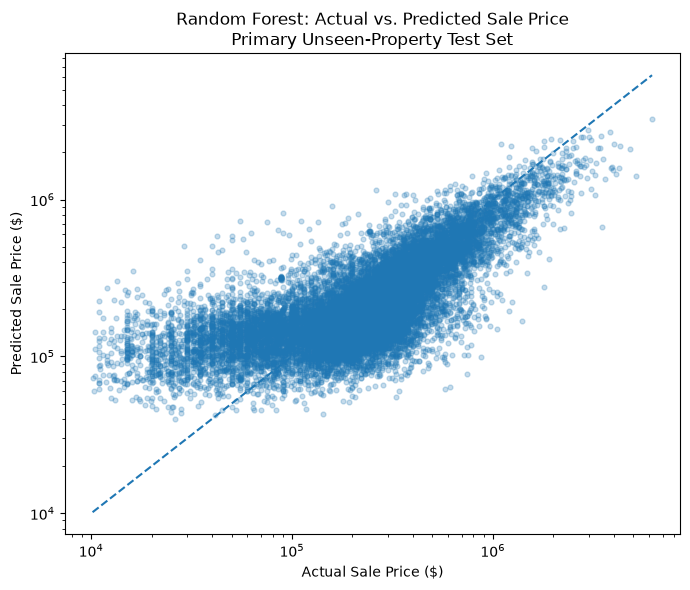

In [85]:
plt.figure(figsize=(7, 6))

plt.scatter(
    y_test,
    rf_pred,
    alpha=0.25,
    s=12
)

plot_min = min(y_test.min(), rf_pred.min())
plot_max = max(y_test.max(), rf_pred.max())

plt.plot(
    [plot_min, plot_max],
    [plot_min, plot_max],
    linestyle="--"
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Actual Sale Price ($)")
plt.ylabel("Predicted Sale Price ($)")
plt.title("Random Forest: Actual vs. Predicted Sale Price\nPrimary Unseen-Property Test Set")

plt.tight_layout()
plt.show()

In [86]:
prediction_diagnostics = pd.DataFrame({
    "actual": y_test,
    "predicted": rf_pred
})

prediction_diagnostics["error"] = (
    prediction_diagnostics["predicted"]
    - prediction_diagnostics["actual"]
)

prediction_diagnostics["absolute_error"] = (
    prediction_diagnostics["error"].abs()
)

prediction_diagnostics["percentage_error"] = (
    prediction_diagnostics["error"]
    / prediction_diagnostics["actual"]
    * 100
)

prediction_diagnostics["price_decile"] = pd.qcut(
    prediction_diagnostics["actual"],
    q=10,
    duplicates="drop"
)

price_decile_diagnostics = (
    prediction_diagnostics
    .groupby("price_decile", observed=True)
    .agg(
        n=("actual", "size"),
        median_actual_price=("actual", "median"),
        median_predicted_price=("predicted", "median"),
        MAE=("absolute_error", "mean"),
        median_percentage_error=("percentage_error", "median"),
    )
    .reset_index()
)

price_decile_diagnostics

,price_decile,n,median_actual_price,median_predicted_price,MAE,median_percentage_error
0,"(10162.999, 63721.0]",1907,40000.0,121169.591536,90645.545255,216.523837
1,"(63721.0, 119900.0]",1909,89000.0,139508.249131,63640.107111,57.712254
2,"(119900.0, 165000.0]",1963,145000.0,150753.177618,47003.683562,4.883323
3,"(165000.0, 204000.0]",1850,185000.0,160238.382940,52008.882135,-13.641804
4,"(204000.0, 240000.0]",2022,224000.0,173855.439666,62724.293297,-22.230837
5,"(240000.0, 279000.0]",1788,259995.0,188320.490760,81747.133695,-27.137696
6,"(279000.0, 330000.0]",1918,302000.0,222702.038023,98684.117226,-26.723233
7,"(330000.0, 410000.0]",1901,365000.0,276781.107594,116875.730108,-24.696398
8,"(410000.0, 600000.0]",1908,485000.0,380182.720994,148038.600752,-21.911157
9,"(600000.0, 6200000.0]",1895,829000.0,653728.675182,333090.730411,-27.409487


### Prediction Calibration Across the Price Distribution

The random forest captures the overall ordering of housing values but exhibits
systematic regression toward the center of the price distribution.

In the lowest price decile, where the median observed sale price is approximately
$40,000, the median predicted price is about 121,170. This corresponds to a
median percentage overprediction of approximately 216.5%. Overprediction declines
rapidly across the next two deciles and is close to zero around the third price
decile.

The direction of error reverses for higher-priced properties. Beginning around
the fourth decile, median predictions systematically fall below observed prices.
Across much of the middle and upper price distribution, median underprediction is
approximately 14%–27%. In the highest price decile, the median observed sale price
is approximately $829,000 compared with a median prediction of about 653,729,
corresponding to a 27.4% median underprediction.

The actual-versus-predicted plot shows the same compression visually: low-priced
properties are generally predicted upward toward the center of the distribution,
while high-priced properties are predicted downward.

This price-dependent calibration pattern is important for later fairness analysis.
If demographic groups differ in the distribution of housing prices, aggregate
group error differences may partly reflect this underlying price-level bias.
Fairness results should therefore be interpreted alongside price-stratified model
performance rather than relying only on unconditional group averages.

## 6. Location-Aware Random Forest Benchmark

The primary structural model intentionally excludes geographic variables so that
housing-price prediction can first be evaluated using property characteristics
alone.

Location, however, is a major determinant of housing value. A secondary benchmark
therefore augments the structural feature set with latitude and longitude while
continuing to exclude Census demographic characteristics.

This comparison serves two purposes. First, it measures how much predictive
information is lost when geography is excluded. Second, it provides a controlled
setting for later examining whether the predictive benefit of geographic
information is accompanied by changes in demographic error disparities.

Only latitude and longitude are introduced at this stage. Higher-cardinality
location codes are withheld so that the initial comparison isolates relatively
direct spatial information without adding multiple overlapping geographic
representations.

In [87]:
location_features = [
    "Latitude",
    "Longitude",
]

location_aware_features = (
    primary_features
    + location_features
)

location_numeric_features = (
    numeric_features
    + location_features
)

location_categorical_features = (
    categorical_features.copy()
)

print("Structural features:", len(primary_features))
print("Location-aware features:", len(location_aware_features))

print(
    "New geographic features:",
    sorted(set(location_aware_features) - set(primary_features))
)

Structural features: 36
Location-aware features: 38
New geographic features: ['Latitude', 'Longitude']


In [88]:
X_train_location = train_data[
    location_aware_features
].copy()

X_test_location = test_data[
    location_aware_features
].copy()

X_test_repeated_location = repeated_property_test[
    location_aware_features
].copy()

print("Training:", X_train_location.shape)
print("Primary test:", X_test_location.shape)
print("Repeated-property test:", X_test_repeated_location.shape)

Training: (143170, 38)
Primary test: (19061, 38)
Repeated-property test: (5153, 38)


In [89]:
location_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_preprocessor,
            location_numeric_features,
        ),
        (
            "categorical",
            categorical_preprocessor,
            location_categorical_features,
        ),
    ]
)

In [90]:
rf_location_model = Pipeline(
    steps=[
        ("preprocessor", location_preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=300,
                min_samples_leaf=2,
                max_features="sqrt",
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

rf_location_model.fit(
    X_train_location,
    y_train_log
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](38,)","['Property Class','Land Square Feet','Apartments',...,'Garage Indicator', 'Latitude','Longitude']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,38
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically 

In [91]:
rf_location_pred_train = np.exp(
    rf_location_model.predict(X_train_location)
)

rf_location_pred = np.exp(
    rf_location_model.predict(X_test_location)
)

rf_location_pred_repeated = np.exp(
    rf_location_model.predict(X_test_repeated_location)
)

In [92]:
rf_location_train_metrics = evaluate_price_predictions(
    y_train,
    rf_location_pred_train
)

rf_location_primary_metrics = evaluate_price_predictions(
    y_test,
    rf_location_pred
)

rf_location_repeated_metrics = evaluate_price_predictions(
    y_test_repeated,
    rf_location_pred_repeated
)

rf_location_results = pd.DataFrame(
    {
        "Training": rf_location_train_metrics,
        "Primary unseen-property test":
            rf_location_primary_metrics,
        "Repeated-property test":
            rf_location_repeated_metrics,
    }
).T

rf_location_results["MAPE"] *= 100

rf_location_results

,MAE,RMSE,Median AE,MAPE,R2
Training,53830.881719,120330.918010,29716.229408,25.233989,0.866079
Primary unseen-property test,75125.352350,141241.781196,45156.509495,33.931962,0.802213
Repeated-property test,103210.896419,168445.488014,72327.159523,33.013231,0.755108


In [93]:
structural_vs_location = pd.DataFrame(
    {
        "Structural RF": rf_primary_metrics,
        "Location-aware RF": rf_location_primary_metrics,
    }
).T

structural_vs_location["MAPE"] *= 100

structural_vs_location

,MAE,RMSE,Median AE,MAPE,R2
Structural RF,109173.105414,181150.845766,73190.702506,60.505130,0.674650
Location-aware RF,75125.352350,141241.781196,45156.509495,33.931962,0.802213


In [94]:
for metric in ["MAE", "RMSE", "Median AE"]:
    improvement = (
        rf_primary_metrics[metric]
        - rf_location_primary_metrics[metric]
    ) / rf_primary_metrics[metric] * 100

    print(
        f"{metric} improvement from adding location: "
        f"{improvement:.2f}%"
    )

mape_location_improvement = (
    rf_primary_metrics["MAPE"]
    - rf_location_primary_metrics["MAPE"]
) / rf_primary_metrics["MAPE"] * 100

print(
    "MAPE improvement from adding location: "
    f"{mape_location_improvement:.2f}%"
)

MAE improvement from adding location: 31.19%
RMSE improvement from adding location: 22.03%
Median AE improvement from adding location: 38.30%
MAPE improvement from adding location: 43.92%


### Predictive Value of Geographic Information

Adding latitude and longitude substantially improves housing-price prediction.

On the primary unseen-property 2019 test set, MAE decreases from approximately
$109,173 for the structural random forest to 75,125 for the location-aware model.
RMSE decreases from about 181,151 to 141,242, while median absolute error falls
from approximately 73,191 to 45,157.

Relative to the structural model, these changes correspond to reductions of
approximately 31.2% in MAE, 22.0% in RMSE, 38.3% in median absolute error, and
43.9% in MAPE. Dollar-scale R² increases from approximately 0.675 to 0.802.

The magnitude of this improvement demonstrates that geographic location contains
substantial information about market value beyond the observed structural
characteristics of the property. Importantly, this improvement is obtained using
only latitude and longitude; Census demographic variables remain excluded from
the predictive model.

The result also motivates a central fairness question for the project. Geography
can improve predictive accuracy while simultaneously encoding spatial patterns
associated with socioeconomic and demographic segregation. The location-aware
model is therefore treated as a benchmark whose accuracy gains and later fairness
outcomes will be evaluated jointly rather than assuming that greater predictive
accuracy necessarily implies a preferable assessment model.

In [95]:
location_diagnostics = pd.DataFrame({
    "actual": y_test,
    "predicted": rf_location_pred
})

location_diagnostics["percentage_error"] = (
    (
        location_diagnostics["predicted"]
        - location_diagnostics["actual"]
    )
    / location_diagnostics["actual"]
    * 100
)

# Use the same actual-price deciles as the structural model
location_diagnostics["price_decile"] = (
    prediction_diagnostics["price_decile"].values
)

location_decile_diagnostics = (
    location_diagnostics
    .groupby("price_decile", observed=True)
    .agg(
        n=("actual", "size"),
        median_actual_price=("actual", "median"),
        median_predicted_price=("predicted", "median"),
        median_percentage_error=("percentage_error", "median"),
    )
    .reset_index()
)

location_decile_diagnostics

,price_decile,n,median_actual_price,median_predicted_price,median_percentage_error
0,"(10162.999, 63721.0]",1907,40000.0,64698.667336,73.885313
1,"(63721.0, 119900.0]",1909,89000.0,92786.441782,8.657812
2,"(119900.0, 165000.0]",1963,145000.0,135441.027637,-7.500466
3,"(165000.0, 204000.0]",1850,185000.0,167267.142332,-9.718450
4,"(204000.0, 240000.0]",2022,224000.0,193950.062490,-13.206074
5,"(240000.0, 279000.0]",1788,259995.0,229142.296915,-11.797037
6,"(279000.0, 330000.0]",1918,302000.0,271325.655398,-10.601868
7,"(330000.0, 410000.0]",1901,365000.0,317691.225808,-12.109795
8,"(410000.0, 600000.0]",1908,485000.0,423411.999317,-12.840524
9,"(600000.0, 6200000.0]",1895,829000.0,705509.483075,-18.335937


In [96]:
decile_calibration_comparison = pd.DataFrame({
    "price_decile": range(1, len(price_decile_diagnostics) + 1),
    "median_actual_price":
        price_decile_diagnostics["median_actual_price"].values,
    "Structural RF":
        price_decile_diagnostics["median_percentage_error"].values,
    "Location-aware RF":
        location_decile_diagnostics["median_percentage_error"].values,
})

decile_calibration_comparison

,price_decile,median_actual_price,Structural RF,Location-aware RF
0,1,40000.0,216.523837,73.885313
1,2,89000.0,57.712254,8.657812
2,3,145000.0,4.883323,-7.500466
3,4,185000.0,-13.641804,-9.718450
4,5,224000.0,-22.230837,-13.206074
5,6,259995.0,-27.137696,-11.797037
6,7,302000.0,-26.723233,-10.601868
7,8,365000.0,-24.696398,-12.109795
8,9,485000.0,-21.911157,-12.840524
9,10,829000.0,-27.409487,-18.335937


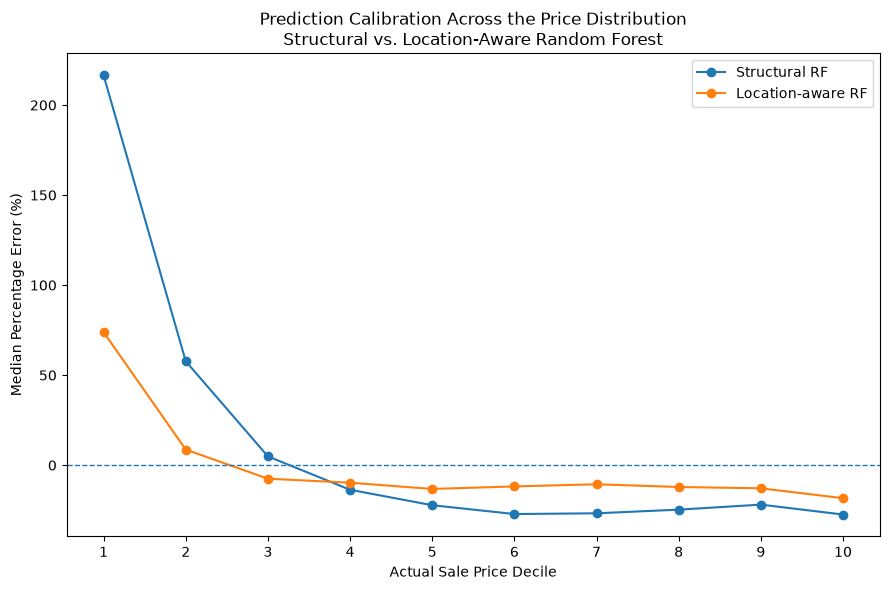

In [97]:
plt.figure(figsize=(9, 6))

plt.plot(
    decile_calibration_comparison["price_decile"],
    decile_calibration_comparison["Structural RF"],
    marker="o",
    label="Structural RF"
)

plt.plot(
    decile_calibration_comparison["price_decile"],
    decile_calibration_comparison["Location-aware RF"],
    marker="o",
    label="Location-aware RF"
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Actual Sale Price Decile")
plt.ylabel("Median Percentage Error (%)")
plt.title(
    "Prediction Calibration Across the Price Distribution\n"
    "Structural vs. Location-Aware Random Forest"
)

plt.xticks(range(1, 11))
plt.legend()
plt.tight_layout()
plt.show()

### Effect of Geography on Price-Level Calibration

Geographic information improves not only aggregate predictive accuracy but also
calibration across the housing-price distribution.

The largest improvement occurs among low-priced properties. In the lowest sale-price
decile, the structural model overpredicts by a median of approximately 216.5%,
whereas the location-aware model reduces this error to about 73.9%. In the second
decile, median overprediction falls from approximately 57.7% to 8.7%.

Location also reduces systematic underprediction among more expensive properties.
For example, median percentage error in the highest price decile improves from
approximately -27.4% for the structural model to -18.3% after latitude and longitude
are added. Across much of the middle and upper price distribution, the location-aware
model's median underprediction is approximately 10%–13%, substantially smaller than
that of the structural model.

These results indicate that omission of geographic information explains a meaningful
portion of the structural model's regression toward the center of the price
distribution. However, a residual calibration pattern remains: very low-priced
properties continue to be overpredicted, while most middle- and high-priced
properties remain moderately underpredicted.

The remaining pattern motivates testing whether a more flexible boosting model can
further improve predictive accuracy and price-level calibration without changing
the underlying information available to the model.

## 7. Histogram Gradient Boosting Model

The location-aware random forest substantially improves both overall accuracy and
price-level calibration, but systematic overprediction at the bottom of the market
and underprediction across much of the upper distribution remain.

To determine whether this remaining pattern is partly attributable to the learning
algorithm rather than the available predictors, a histogram gradient boosting
regressor is fit using the same location-aware feature set.

Unlike random forests, which average many independently constructed trees, gradient
boosting builds trees sequentially so that each stage attempts to correct errors
remaining from earlier stages. This can provide greater predictive flexibility for
structured tabular data.

The predictor information and temporal evaluation design remain unchanged, allowing
the comparison with the location-aware random forest to isolate the effect of the
modeling algorithm.

In [100]:
categorical_cardinality = (
    X_train_location[
        location_categorical_features
    ]
    .nunique(dropna=True)
    .sort_values(ascending=False)
)

categorical_cardinality

Sale Month of Year          12
Property Class               9
Roof Material                6
Garage 1 Material            5
Multi Code                   4
Basement                     4
Wall Material                4
Garage 2 Area                4
Central Heating              3
Attic Finish                 3
Attic Type                   3
Porch                        3
Garage 2 Attachment          3
Repair Condition             3
Design Plan                  3
Garage 1 Area                3
Garage 2 Material            3
Garage 1 Attachment          3
Cathedral Ceiling            3
Central Air                  2
Other Heating                2
Basement Finish              2
Multi Property Indicator     2
O'Hare Noise                 2
Floodplain                   2
Road Proximity               2
Garage Indicator             2
dtype: int64

In [101]:
print(
    "Maximum categorical cardinality:",
    categorical_cardinality.max()
)

print(
    "Features with more than 255 categories:",
    (
        categorical_cardinality[
            categorical_cardinality > 255
        ]
        .index
        .tolist()
    )
)

Maximum categorical cardinality: 12
Features with more than 255 categories: []


In [102]:
hgb_numeric_preprocessor = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
    ]
)

hgb_categorical_preprocessor = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "ordinal",
            OrdinalEncoder(
                handle_unknown="use_encoded_value",
                unknown_value=-1,
            )
        ),
    ]
)

hgb_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            hgb_numeric_preprocessor,
            location_numeric_features,
        ),
        (
            "categorical",
            hgb_categorical_preprocessor,
            location_categorical_features,
        ),
    ]
)

In [103]:
hgb_categorical_mask = (
    [False] * len(location_numeric_features)
    + [True] * len(location_categorical_features)
)

print(
    "Total transformed input features:",
    len(hgb_categorical_mask)
)

print(
    "Numeric features:",
    sum(~np.array(hgb_categorical_mask))
)

print(
    "Categorical features:",
    sum(hgb_categorical_mask)
)

Total transformed input features: 38
Numeric features: 11
Categorical features: 27


In [104]:
hgb_location_model = Pipeline(
    steps=[
        (
            "preprocessor",
            hgb_preprocessor
        ),
        (
            "model",
            HistGradientBoostingRegressor(
                learning_rate=0.08,
                max_iter=300,
                max_leaf_nodes=31,
                min_samples_leaf=20,
                l2_regularization=1.0,
                categorical_features=hgb_categorical_mask,
                random_state=42,
            )
        ),
    ]
)

hgb_location_model.fit(
    X_train_location,
    y_train_log
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](38,)","['Property Class','Land Square Feet','Apartments',...,'Garage Indicator', 'Latitude','Longitude']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,38
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically 

In [105]:
hgb_location_pred_train = np.exp(
    hgb_location_model.predict(
        X_train_location
    )
)

hgb_location_pred = np.exp(
    hgb_location_model.predict(
        X_test_location
    )
)

hgb_location_pred_repeated = np.exp(
    hgb_location_model.predict(
        X_test_repeated_location
    )
)

In [106]:
hgb_location_train_metrics = evaluate_price_predictions(
    y_train,
    hgb_location_pred_train
)

hgb_location_primary_metrics = evaluate_price_predictions(
    y_test,
    hgb_location_pred
)

hgb_location_repeated_metrics = evaluate_price_predictions(
    y_test_repeated,
    hgb_location_pred_repeated
)

hgb_location_results = pd.DataFrame(
    {
        "Training":
            hgb_location_train_metrics,
        "Primary unseen-property test":
            hgb_location_primary_metrics,
        "Repeated-property test":
            hgb_location_repeated_metrics,
    }
).T

hgb_location_results["MAPE"] *= 100

hgb_location_results

,MAE,RMSE,Median AE,MAPE,R2
Training,62850.280871,122956.173093,37764.936924,30.944249,0.860172
Primary unseen-property test,64471.548255,114877.130736,40276.971048,30.912923,0.869161
Repeated-property test,83117.535813,132891.285590,58373.280993,29.003145,0.847578


In [107]:
location_model_comparison = pd.DataFrame(
    {
        "Location-aware RF":
            rf_location_primary_metrics,
        "Location-aware HGB":
            hgb_location_primary_metrics,
    }
).T

location_model_comparison["MAPE"] *= 100

location_model_comparison

,MAE,RMSE,Median AE,MAPE,R2
Location-aware RF,75125.352350,141241.781196,45156.509495,33.931962,0.802213
Location-aware HGB,64471.548255,114877.130736,40276.971048,30.912923,0.869161


In [109]:
for metric in ["MAE", "RMSE", "Median AE"]:
    improvement = (
        rf_location_primary_metrics[metric]
        - hgb_location_primary_metrics[metric]
    ) / rf_location_primary_metrics[metric] * 100

    print(
        f"{metric} improvement from RF to HGB: "
        f"{improvement:.2f}%"
    )

hgb_mape_improvement = (
    rf_location_primary_metrics["MAPE"]
    - hgb_location_primary_metrics["MAPE"]
) / rf_location_primary_metrics["MAPE"] * 100

print(
    "MAPE improvement from RF to HGB: "
    f"{hgb_mape_improvement:.2f}%"
)

print(
    "R² change from RF to HGB:",
    round(
        hgb_location_primary_metrics["R2"]
        - rf_location_primary_metrics["R2"],
        4
    )
)

MAE improvement from RF to HGB: 14.18%
RMSE improvement from RF to HGB: 18.67%
Median AE improvement from RF to HGB: 10.81%
MAPE improvement from RF to HGB: 8.90%
R² change from RF to HGB: 0.0669


### Histogram Gradient Boosting Performance and Calibration

The aggregate evaluation metrics indicate whether Histogram Gradient Boosting improves overall predictive performance relative to the previously evaluated random-forest models. However, aggregate accuracy alone is not sufficient for selecting the final predictive model.

Earlier calibration analysis showed that the structural random forest systematically overpredicted lower-priced properties while underpredicting middle- and higher-priced properties. Adding location information substantially reduced this pattern, but did not eliminate it.

Therefore, this section evaluates the location-aware Histogram Gradient Boosting model from two complementary perspectives:

1. **Overall predictive performance**, using MAE, RMSE, Median Absolute Error, MAPE, and $R^2\$.
2. **Calibration across the property-price distribution**, using median signed percentage error within actual sale-price deciles.

The goal is to determine whether Histogram Gradient Boosting improves not only aggregate predictive accuracy, but also the systematic price-dependent errors observed in the earlier models. These results will determine which model should serve as the primary predictive benchmark for the subsequent fairness analysis.

In [110]:
# Combine the major primary-test model results
overall_model_comparison = pd.DataFrame(
    {
        "Naive baseline": baseline_primary_metrics,
        "Structural RF": rf_primary_metrics,
        "Location-aware RF": rf_location_primary_metrics,
        "Location-aware HGB": hgb_location_primary_metrics,
    }
).T

# Convert MAPE from proportion to percentage
overall_model_comparison["MAPE"] *= 100

overall_model_comparison

,MAE,RMSE,Median AE,MAPE,R2
Naive baseline,181708.448227,338627.917599,106098.407435,91.868364,-0.136884
Structural RF,109173.105414,181150.845766,73190.702506,60.505130,0.674650
Location-aware RF,75125.352350,141241.781196,45156.509495,33.931962,0.802213
Location-aware HGB,64471.548255,114877.130736,40276.971048,30.912923,0.869161


In [111]:
hgb_diagnostics = pd.DataFrame({
    "actual": y_test,
    "predicted": hgb_location_pred
})

hgb_diagnostics["error"] = (
    hgb_diagnostics["predicted"]
    - hgb_diagnostics["actual"]
)

hgb_diagnostics["absolute_error"] = (
    hgb_diagnostics["error"].abs()
)

hgb_diagnostics["percentage_error"] = (
    hgb_diagnostics["error"]
    / hgb_diagnostics["actual"]
    * 100
)

# Use exactly the same actual-price deciles previously defined for the structural model
hgb_diagnostics["price_decile"] = (
    prediction_diagnostics["price_decile"].values
)

hgb_decile_diagnostics = (
    hgb_diagnostics
    .groupby("price_decile", observed=True)
    .agg(
        n=("actual", "size"),
        median_actual_price=("actual", "median"),
        median_predicted_price=("predicted", "median"),
        MAE=("absolute_error", "mean"),
        median_percentage_error=("percentage_error", "median"),
    )
    .reset_index()
)

hgb_decile_diagnostics

,price_decile,n,median_actual_price,median_predicted_price,MAE,median_percentage_error
0,"(10162.999, 63721.0]",1907,40000.0,60268.435668,32050.927434,63.172281
1,"(63721.0, 119900.0]",1909,89000.0,98713.697820,40885.684246,14.964726
2,"(119900.0, 165000.0]",1963,145000.0,145546.999130,48720.923276,-0.921872
3,"(165000.0, 204000.0]",1850,185000.0,181529.439896,46254.916833,-1.962013
4,"(204000.0, 240000.0]",2022,224000.0,211052.682000,46220.753336,-5.431528
5,"(240000.0, 279000.0]",1788,259995.0,246795.363733,46528.779348,-4.827340
6,"(279000.0, 330000.0]",1918,302000.0,295066.937151,49217.236674,-3.042410
7,"(330000.0, 410000.0]",1901,365000.0,344841.271753,60444.454856,-5.353953
8,"(410000.0, 600000.0]",1908,485000.0,457500.023803,86032.976654,-6.077829
9,"(600000.0, 6200000.0]",1895,829000.0,790944.828989,189130.983705,-8.292736


In [112]:
calibration_comparison = pd.DataFrame({
    "price_decile": range(
        1,
        len(price_decile_diagnostics) + 1
    ),

    "median_actual_price":
        price_decile_diagnostics[
            "median_actual_price"
        ].values,

    "Structural RF":
        price_decile_diagnostics[
            "median_percentage_error"
        ].values,

    "Location-aware RF":
        location_decile_diagnostics[
            "median_percentage_error"
        ].values,

    "Location-aware HGB":
        hgb_decile_diagnostics[
            "median_percentage_error"
        ].values,
})

calibration_comparison

,price_decile,median_actual_price,Structural RF,Location-aware RF,Location-aware HGB
0,1,40000.0,216.523837,73.885313,63.172281
1,2,89000.0,57.712254,8.657812,14.964726
2,3,145000.0,4.883323,-7.500466,-0.921872
3,4,185000.0,-13.641804,-9.718450,-1.962013
4,5,224000.0,-22.230837,-13.206074,-5.431528
5,6,259995.0,-27.137696,-11.797037,-4.827340
6,7,302000.0,-26.723233,-10.601868,-3.042410
7,8,365000.0,-24.696398,-12.109795,-5.353953
8,9,485000.0,-21.911157,-12.840524,-6.077829
9,10,829000.0,-27.409487,-18.335937,-8.292736


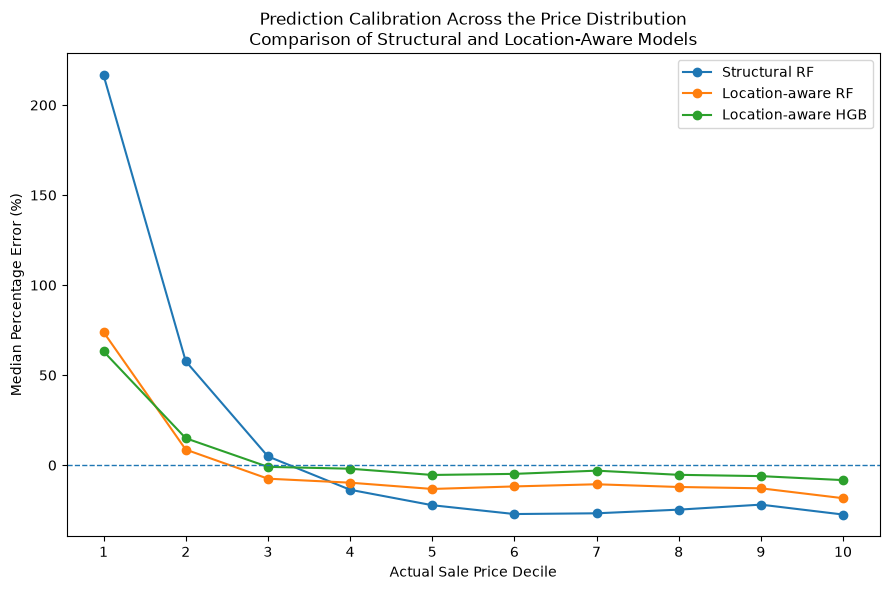

In [113]:
plt.figure(figsize=(9, 6))

plt.plot(
    calibration_comparison["price_decile"],
    calibration_comparison["Structural RF"],
    marker="o",
    label="Structural RF"
)

plt.plot(
    calibration_comparison["price_decile"],
    calibration_comparison["Location-aware RF"],
    marker="o",
    label="Location-aware RF"
)

plt.plot(
    calibration_comparison["price_decile"],
    calibration_comparison["Location-aware HGB"],
    marker="o",
    label="Location-aware HGB"
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Actual Sale Price Decile")
plt.ylabel("Median Percentage Error (%)")

plt.title(
    "Prediction Calibration Across the Price Distribution\n"
    "Comparison of Structural and Location-Aware Models"
)

plt.xticks(range(1, 11))

plt.legend()

plt.tight_layout()
plt.show()

### Histogram Gradient Boosting Performance and Calibration

The location-aware Histogram Gradient Boosting (HGB) model produced the strongest predictive performance among all models evaluated on the primary unseen-property test set.

Its Mean Absolute Error decreased from approximately **75,125** for the location-aware random forest to **64,472**, representing an improvement of approximately **14.2%**. RMSE decreased from approximately **141,242** to **114,877**, an improvement of approximately **18.7%**, while Median Absolute Error declined from approximately **45,157** to **40,277**.

Relative prediction accuracy also improved. MAPE decreased from **33.93%** for the location-aware random forest to **30.91%** for HGB. At the same time, $R^2$ increased from **0.802** to **0.869**, indicating that HGB explains substantially more of the variation in unseen property sale prices.

The price-decile calibration analysis provides additional evidence in favor of HGB. The original structural random forest exhibited a pronounced price-dependent error pattern: it substantially overpredicted inexpensive properties while systematically underpredicting properties in the middle and upper portions of the price distribution. Adding location information substantially reduced this bias, and HGB reduced it further across most price groups.

The largest remaining calibration problem occurs among properties in the lowest sale-price decile. HGB produces a median percentage error of approximately **+63.2%**, meaning that these properties remain substantially overpredicted. Nevertheless, this represents a notable improvement over the **+73.9%** median error of the location-aware random forest and the extreme **+216.5%** median error of the structural random forest.

The second price decile is one exception to HGB's otherwise stronger calibration. HGB produces a median percentage error of approximately **+15.0%**, compared with approximately **+8.7%** for the location-aware random forest. Therefore, HGB does not outperform the location-aware random forest in every individual price segment.

From the third decile onward, however, HGB is consistently better calibrated. Its median percentage errors remain relatively close to zero, ranging from approximately **−0.9% to −8.3%** across deciles 3 through 10. In comparison, the location-aware random forest produces errors ranging roughly from **−7.5% to −18.3%** across the same portion of the distribution.

The improvement is especially noticeable in higher-value properties. For the highest-price decile, the median percentage error improves from approximately **−27.4%** under the structural random forest and **−18.3%** under the location-aware random forest to approximately **−8.3%** under HGB.

Overall, Histogram Gradient Boosting reduces both major calibration problems observed in the earlier models: extreme overprediction among very inexpensive properties and systematic underprediction among middle- and high-value properties. However, calibration is not completely uniform. The model continues to overpredict the lowest-value properties, while predictions become slightly negatively biased beginning around the third price decile.

This remaining price-dependent error pattern is particularly important for the subsequent fairness analysis. If socioeconomic or demographic neighborhood groups differ systematically in their underlying property-value distributions, apparent subgroup disparities may partly reflect this residual relationship between prediction error and property price. Fairness results should therefore be interpreted alongside the model's price calibration.

Considering both aggregate predictive performance and calibration across the sale-price distribution, the **location-aware Histogram Gradient Boosting model is selected as the primary predictive model for the remainder of the analysis**. The location-aware random forest will remain useful as a secondary comparison model when evaluating whether observed subgroup disparities are specific to HGB or persist across different modeling approaches.

## 8. Fairness Evaluation Across Census-Tract Groups

Achieving strong overall predictive accuracy does not necessarily imply that a housing-price model performs equally well across different communities. A model may exhibit relatively low aggregate error while producing systematically larger errors or different directions of error for properties located in neighborhoods with different socioeconomic or demographic characteristics.

The fairness analysis therefore evaluates whether prediction errors from the selected location-aware Histogram Gradient Boosting model are distributed differently across Census-tract groups defined using American Community Survey (ACS) characteristics.

Because the ACS variables describe **Census-tract populations rather than individual property owners or buyers**, these variables should not be interpreted as individual-level protected characteristics. Accordingly, this analysis is best understood as a **neighborhood-level prediction disparity audit**, rather than direct evidence of individual-level discrimination.

## 8.1 Socioeconomic Fairness Evaluation: Income and Poverty

The first subgroup analysis examines whether prediction errors differ systematically across neighborhoods with different socioeconomic conditions.

Two Census-tract characteristics are considered:

- **Median household income**, representing the general income level of households within each tract.
- **Poverty rate**, representing the proportion of the tract population whose income falls below the federal poverty threshold.

These ACS variables were deliberately excluded from the model's predictor set and reserved for fairness evaluation. Therefore, any differences observed across these groups reflect variation in model performance across neighborhood contexts rather than the direct use of income or poverty information as predictive features.

The analysis uses the primary 2019 unseen-property test set and evaluates the selected location-aware Histogram Gradient Boosting model. Neighborhoods will be divided into quartile-based groups separately for income and poverty. Quartiles provide groups of roughly comparable sample size while preserving an interpretable ordering from lower to higher socioeconomic values.

For each group, model performance will be evaluated using both error magnitude and error direction:

- **MAE** measures average dollar error.
- **Median Absolute Error** measures typical dollar error while reducing sensitivity to extreme predictions.
- **MAPE** measures prediction error relative to the actual sale price.
- **Mean Signed Error** identifies systematic dollar overprediction or underprediction.
- **Median Percentage Error** identifies the typical proportional direction of error.
- **Median Actual Sale Price** helps determine whether subgroup disparities may partly reflect the price-dependent calibration pattern identified earlier.

Including sale-price information is particularly important because the previous analysis showed that HGB still tends to overpredict the lowest-priced properties and modestly underpredict much of the remaining price distribution. Socioeconomic disparities must therefore be interpreted jointly with differences in the underlying property-price distributions of the groups.

In [120]:
# Build fairness evaluation data from the original primary test observations.
# test_data retains ACS variables that were excluded from model predictors.

fairness_eval = test_data.copy()

# Verify that row order matches the prediction matrix
print("Test data rows:", len(fairness_eval))
print("HGB predictions:", len(hgb_location_pred))

fairness_eval["actual_sale_price"] = y_test.values
fairness_eval["predicted_sale_price"] = hgb_location_pred

fairness_eval["signed_error"] = (
    fairness_eval["predicted_sale_price"]
    - fairness_eval["actual_sale_price"]
)

fairness_eval["absolute_error"] = (
    fairness_eval["signed_error"].abs()
)

fairness_eval["percentage_error"] = (
    fairness_eval["signed_error"]
    / fairness_eval["actual_sale_price"]
    * 100
)

fairness_eval["absolute_percentage_error"] = (
    fairness_eval["percentage_error"].abs()
)

print("\nFairness variables available:")
print(
    fairness_eval[
        [
            "median_household_income",
            "poverty_rate",
            "pct_white_non_hispanic",
            "pct_black_non_hispanic",
            "pct_asian_non_hispanic",
            "pct_hispanic"
        ]
    ].isna().sum()
)

Test data rows: 19061
HGB predictions: 19061

Fairness variables available:
median_household_income    0
poverty_rate               0
pct_white_non_hispanic     0
pct_black_non_hispanic     0
pct_asian_non_hispanic     0
pct_hispanic               0
dtype: int64


In [121]:
fairness_eval["income_quartile"] = pd.qcut(
    fairness_eval["median_household_income"],
    q=4,
    labels=[
        "Q1: Lowest income",
        "Q2",
        "Q3",
        "Q4: Highest income"
    ]
)

fairness_eval["poverty_quartile"] = pd.qcut(
    fairness_eval["poverty_rate"],
    q=4,
    labels=[
        "Q1: Lowest poverty",
        "Q2",
        "Q3",
        "Q4: Highest poverty"
    ]
)

print("Income quartile counts:")
print(
    fairness_eval["income_quartile"]
    .value_counts()
    .sort_index()
)

print("\nPoverty quartile counts:")
print(
    fairness_eval["poverty_quartile"]
    .value_counts()
    .sort_index()
)

Income quartile counts:
income_quartile
Q1: Lowest income     4791
Q2                    4770
Q3                    4785
Q4: Highest income    4715
Name: count, dtype: int64

Poverty quartile counts:
poverty_quartile
Q1: Lowest poverty     4777
Q2                     4760
Q3                     4773
Q4: Highest poverty    4751
Name: count, dtype: int64


In [124]:
def summarize_fairness_by_group(df, group_col):
    return (
        df
        .groupby(group_col, observed=True)
        .agg(
            n=("actual_sale_price", "size"),

            median_actual_sale_price=(
                "actual_sale_price",
                "median"
            ),

            MAE=(
                "absolute_error",
                "mean"
            ),

            median_absolute_error=(
                "absolute_error",
                "median"
            ),

            MAPE=(
                "absolute_percentage_error",
                "mean"
            ),

            mean_signed_error=(
                "signed_error",
                "mean"
            ),

            median_percentage_error=(
                "percentage_error",
                "median"
            )
        )
        .reset_index()
    )

In [125]:
income_fairness = summarize_fairness_by_group(
    fairness_eval,
    "income_quartile"
)

poverty_fairness = summarize_fairness_by_group(
    fairness_eval,
    "poverty_quartile"
)

print("Income-based fairness metrics:")
display(income_fairness)

print("\nPoverty-based fairness metrics:")
display(poverty_fairness)

Income-based fairness metrics:


,income_quartile,n,median_actual_sale_price,MAE,median_absolute_error,MAPE,mean_signed_error,median_percentage_error
0,Q1: Lowest income,4791,105000.0,45376.606114,32145.174652,50.564355,-5472.103420,2.167568
1,Q2,4770,209999.5,51685.250001,37705.957373,30.186674,-5083.432763,-2.990562
2,Q3,4785,265000.0,54653.725326,37361.529543,21.585308,-4246.899365,-0.734150
3,Q4: Highest income,4715,435000.0,106773.307151,62810.131981,21.145548,-17651.749800,-1.743563



Poverty-based fairness metrics:


,poverty_quartile,n,median_actual_sale_price,MAE,median_absolute_error,MAPE,mean_signed_error,median_percentage_error
0,Q1: Lowest poverty,4777,352500.0,82925.883773,50163.475860,20.467288,-13970.935552,-2.182672
1,Q2,4760,275000.0,69344.982558,44142.048056,23.143569,-5689.080954,-1.305192
2,Q3,4773,215000.0,57820.150449,38317.803446,31.499194,-3775.048069,-1.176144
3,Q4: Highest poverty,4751,110000.0,47715.752356,32331.621608,48.610806,-8877.446144,0.469608


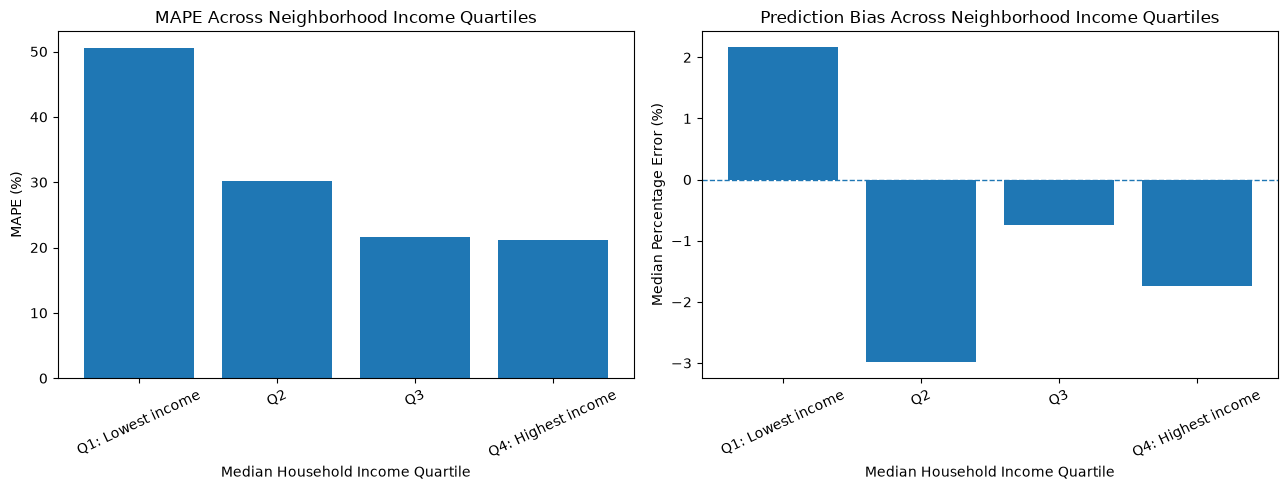

In [126]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5)
)

axes[0].bar(
    income_fairness["income_quartile"].astype(str),
    income_fairness["MAPE"]
)

axes[0].set_title(
    "MAPE Across Neighborhood Income Quartiles"
)
axes[0].set_xlabel("Median Household Income Quartile")
axes[0].set_ylabel("MAPE (%)")
axes[0].tick_params(axis="x", rotation=25)

axes[1].bar(
    income_fairness["income_quartile"].astype(str),
    income_fairness["median_percentage_error"]
)

axes[1].axhline(
    0,
    linestyle="--",
    linewidth=1
)

axes[1].set_title(
    "Prediction Bias Across Neighborhood Income Quartiles"
)
axes[1].set_xlabel("Median Household Income Quartile")
axes[1].set_ylabel("Median Percentage Error (%)")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

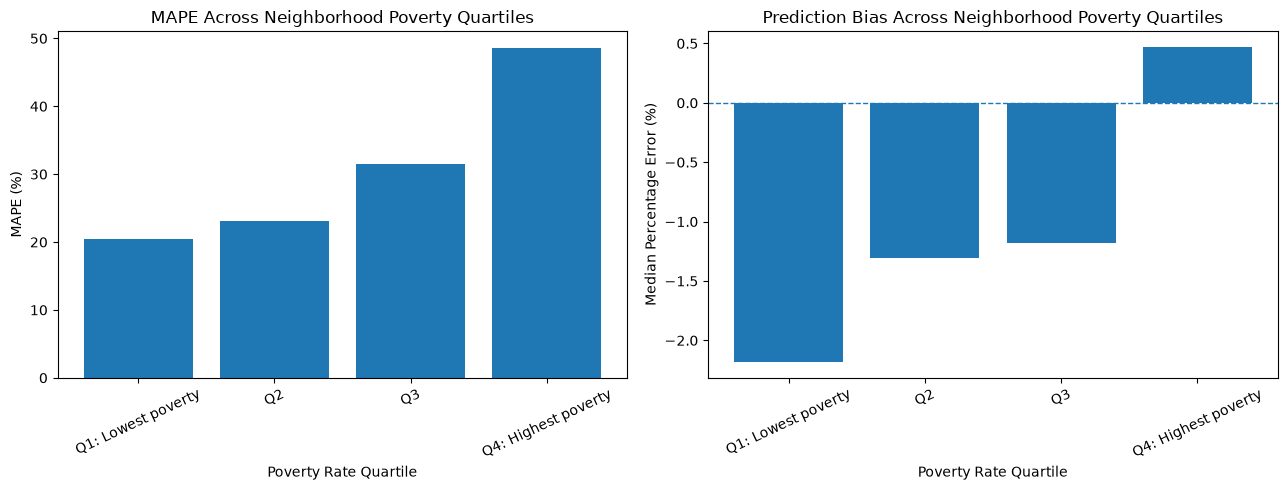

In [127]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5)
)

axes[0].bar(
    poverty_fairness["poverty_quartile"].astype(str),
    poverty_fairness["MAPE"]
)

axes[0].set_title(
    "MAPE Across Neighborhood Poverty Quartiles"
)
axes[0].set_xlabel("Poverty Rate Quartile")
axes[0].set_ylabel("MAPE (%)")
axes[0].tick_params(axis="x", rotation=25)

axes[1].bar(
    poverty_fairness["poverty_quartile"].astype(str),
    poverty_fairness["median_percentage_error"]
)

axes[1].axhline(
    0,
    linestyle="--",
    linewidth=1
)

axes[1].set_title(
    "Prediction Bias Across Neighborhood Poverty Quartiles"
)
axes[1].set_xlabel("Poverty Rate Quartile")
axes[1].set_ylabel("Median Percentage Error (%)")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

### Analysis

The socioeconomic subgroup analysis reveals substantial differences in model performance across Census tracts, but the direction of the disparity depends on whether prediction error is measured in dollars or relative to property value.

For neighborhood income, Mean Absolute Percentage Error (MAPE) decreases sharply as median household income increases. Properties in the lowest-income quartile have a MAPE of approximately **50.6%**, compared with **30.2%** in the second quartile, **21.6%** in the third quartile, and **21.1%** in the highest-income quartile. Thus, relative prediction error for the lowest-income neighborhoods is more than twice that observed in the two highest-income quartiles.

The poverty analysis exhibits the corresponding pattern in the opposite socioeconomic direction. MAPE rises monotonically from approximately **20.5%** in the lowest-poverty quartile to **23.1%**, **31.5%**, and finally **48.6%** in the highest-poverty quartile. This indicates that the model is substantially less accurate relative to property value in economically disadvantaged neighborhoods.

However, dollar-denominated errors produce a different pattern. For the income groups, MAE increases from approximately **45,377** in the lowest-income quartile to **106,773** in the highest-income quartile. Similarly, MAE decreases from approximately **82,926** in the lowest-poverty quartile to approximately **47,716** in the highest-poverty quartile.

This apparent reversal is closely related to differences in the underlying housing-price distributions. Median sale price rises from approximately **105,000** in the lowest-income quartile to **435,000** in the highest-income quartile. Likewise, median sale price falls from approximately **352,500** in the lowest-poverty quartile to only **110,000** in the highest-poverty quartile. A similar proportional prediction error therefore corresponds to a much larger dollar error for properties in more expensive neighborhoods.

For this reason, MAE alone would provide an incomplete picture of socioeconomic model performance. Although higher-income and lower-poverty neighborhoods experience larger absolute dollar errors, lower-income and higher-poverty neighborhoods experience substantially larger errors relative to the value of their properties. The percentage-based metrics are therefore especially important when comparing neighborhoods whose housing-price distributions differ substantially.

The signed-error measures provide a more nuanced picture of directional bias. Median percentage error remains comparatively close to zero across all socioeconomic quartiles. For income groups, median percentage error ranges from approximately **+2.2%** in the lowest-income quartile to between approximately **−0.7% and −3.0%** in the remaining quartiles. For poverty groups, it ranges from approximately **−2.2%** in the lowest-poverty quartile to approximately **+0.5%** in the highest-poverty quartile.

These values suggest that the large socioeconomic differences in MAPE are driven primarily by differences in **error magnitude rather than strong systematic overvaluation or undervaluation of the typical property**. In other words, predictions are substantially less precise in disadvantaged neighborhoods, but the median prediction does not show an equally large directional bias.

There is also an important difference between the mean and median signed-error measures. For example, properties in the highest-poverty quartile have a slightly positive median percentage error of approximately **+0.5%**, while their mean signed dollar error is approximately **−8,877**. Similarly, the lowest-income quartile has a positive median percentage error of approximately **+2.2%**, despite a negative mean signed error of approximately **−5,472**. This divergence suggests that the error distributions are asymmetric and that relatively large underprediction errors for some properties influence the mean more strongly than the median.

Overall, the results provide evidence of a clear **socioeconomic disparity in relative predictive accuracy**. Prediction errors are proportionally much larger in lower-income and higher-poverty neighborhoods. At the same time, the relationship between neighborhood socioeconomic status and property value makes it difficult to determine from these raw subgroup comparisons alone whether the disparity is specifically associated with socioeconomic characteristics or is partly inherited from the remaining price-dependent calibration of the model.

Consequently, these results should be interpreted as evidence of a neighborhood-level performance disparity rather than evidence of causal discrimination. A later price-adjusted fairness analysis will be necessary to determine whether socioeconomic disparities persist after accounting for differences in the underlying property-value distributions.

## 8.2 Fairness Evaluation Across Neighborhood Demographic Composition

The second component of the fairness audit examines whether housing-price prediction errors vary with the racial and ethnic composition of Census tracts.

The ACS provides four neighborhood composition measures retained for this analysis:

- percentage of residents who are White and non-Hispanic;
- percentage who are Black and non-Hispanic;
- percentage who are Asian and non-Hispanic;
- percentage who are Hispanic.

These variables describe the aggregate population composition of Census tracts and do not identify the race or ethnicity of individual property owners, buyers, or sellers. The resulting comparisons therefore measure **neighborhood-level performance disparities** and should not be interpreted as individual-level racial prediction errors.

For each demographic composition variable, Census tracts are divided into quartiles from lower to higher population share. The same prediction metrics used in the socioeconomic analysis are then calculated within each quartile.

Particular attention will be given to:

1. whether relative prediction error increases or decreases with neighborhood demographic composition;
2. whether any groups exhibit systematic overprediction or underprediction;
3. whether dollar-error and percentage-error measures lead to different conclusions; and
4. whether observed disparities may be related to differences in the underlying property-price distributions.

As in the socioeconomic analysis, these initial subgroup comparisons are descriptive rather than causal. Because property value itself remains associated with prediction calibration, any demographic disparity identified here will later need to be distinguished from differences that arise because demographic groups are distributed differently across the housing-price spectrum.